# Лабораторная работа №5
## Обучение без учителя. Задача кластеризации

**Выполнил:** Харлов Никита  
**Вариант:** `stud_end.csv` (датасет студентов)

---

### Содержание
| № | Раздел |
|---|--------|
| 1 | Генерация синтетических данных |
| 2 | Загрузка и подготовка stud_end.csv |
| 3 | Подбор гиперпараметров |
| 4 | Кластеризация синтетических данных |
| 5 | Кластеризация stud_end (задача классификации) |
| 6 | Профили кластеров |
| 7 | Оценка качества — метрики |
| 8 | Собственная реализация K-Means |
| 9 | Сводные таблицы результатов |
| 10 | Вывод |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import make_blobs, make_classification
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA

from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN, AffinityPropagation
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import NearestNeighbors
import scipy.cluster.hierarchy as sch

from sklearn.metrics import (
    silhouette_score, davies_bouldin_score,
    adjusted_rand_score, normalized_mutual_info_score
)

# ── Стиль ──────────────────────────────────────────────────────────────
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 12
sns.set_style('whitegrid')
CMAP = 'tab10'
RS = 42  # random_state

# ── Утилиты ────────────────────────────────────────────────────────────
def to_2d(X):
    """PCA-проекция для визуализации многомерных данных."""
    if X.shape[1] > 2:
        return PCA(n_components=2, random_state=RS).fit_transform(X)
    return X

def plot_clusters(ax, X, labels, title, centers=None):
    """Визуализация кластеров (2D или через PCA)."""
    X2 = to_2d(X)
    unique = sorted(set(labels))
    colors = plt.cm.get_cmap(CMAP, max(len(unique), 2))
    for i, lbl in enumerate(unique):
        mask = labels == lbl
        c = 'black' if lbl == -1 else colors(i % 10)
        name = 'Шум' if lbl == -1 else f'Кластер {lbl}'
        ax.scatter(X2[mask, 0], X2[mask, 1], c=[c], alpha=0.65, s=25, label=name)
    if centers is not None and X.shape[1] == 2:
        ax.scatter(centers[:, 0], centers[:, 1],
                   c='red', marker='*', s=220, zorder=5, label='Центроиды')
    ax.set_title(title, fontsize=11)
    ax.legend(fontsize=7, loc='best', ncol=2 if len(unique) > 5 else 1)
    ax.set_xlabel('PC1' if X.shape[1] > 2 else 'x₁')
    ax.set_ylabel('PC2' if X.shape[1] > 2 else 'x₂')

def safe_metrics(X, labels, y_true=None):
    """Считает 4 метрики, обрабатывает шум DBSCAN (метка -1)."""
    mask = labels != -1
    n_clusters = len(set(labels[mask])) if mask.sum() > 0 else 0
    if n_clusters < 2:
        sil, db = None, None
    else:
        sil = silhouette_score(X[mask], labels[mask])
        db  = davies_bouldin_score(X[mask], labels[mask])
    ari = adjusted_rand_score(y_true, labels) if y_true is not None else None
    nmi = normalized_mutual_info_score(y_true, labels) if y_true is not None else None
    return sil, db, ari, nmi

print("Библиотеки загружены.")

Библиотеки загружены.


---
## 1. Генерация синтетических данных

Генерируем **5 датасетов**:
- **2 × `make_blobs`** — чёткие сферические кластеры, идеальны для K-Means
- **3 × `make_classification`** — более сложная структура, разное число классов и признаков

Все датасеты содержат **не менее 3 кластеров** и масштабируются с помощью `StandardScaler`.

In [2]:
scaler = StandardScaler()

# ── make_blobs ──────────────────────────────────────────────────────────
blob1_X, blob1_y = make_blobs(n_samples=300, centers=3, cluster_std=0.8,
                               n_features=2, random_state=RS)
blob2_X, blob2_y = make_blobs(n_samples=400, centers=5, cluster_std=1.0,
                               n_features=2, random_state=7)

blob1_Xs = scaler.fit_transform(blob1_X)
blob2_Xs = scaler.fit_transform(blob2_X)

# ── make_classification ─────────────────────────────────────────────────
clf1_X, clf1_y = make_classification(
    n_samples=300, n_features=4,  n_classes=3, n_clusters_per_class=1,
    n_informative=3, n_redundant=1, random_state=RS)

clf2_X, clf2_y = make_classification(
    n_samples=400, n_features=6,  n_classes=4, n_clusters_per_class=1,
    n_informative=4, n_redundant=2, random_state=17)

clf3_X, clf3_y = make_classification(
    n_samples=500, n_features=8,  n_classes=5, n_clusters_per_class=1,
    n_informative=5, n_redundant=3, random_state=99)

clf1_Xs = scaler.fit_transform(clf1_X)
clf2_Xs = scaler.fit_transform(clf2_X)
clf3_Xs = scaler.fit_transform(clf3_X)

# ── Сводка ──────────────────────────────────────────────────────────────
datasets_info = [
    ("make_blobs #1",    blob1_Xs, blob1_y, "3 кластера, 2 признака"),
    ("make_blobs #2",    blob2_Xs, blob2_y, "5 кластеров, 2 признака"),
    ("make_classif #1",  clf1_Xs,  clf1_y,  "3 класса, 4 признака"),
    ("make_classif #2",  clf2_Xs,  clf2_y,  "4 класса, 6 признаков"),
    ("make_classif #3",  clf3_Xs,  clf3_y,  "5 классов, 8 признаков"),
]
print("Датасеты сформированы:")
for name, X, y, desc in datasets_info:
    print(f"  {name:20s} | {X.shape[0]} объектов, {X.shape[1]} признаков | {desc}")

Датасеты сформированы:
  make_blobs #1        | 300 объектов, 2 признаков | 3 кластера, 2 признака
  make_blobs #2        | 400 объектов, 2 признаков | 5 кластеров, 2 признака
  make_classif #1      | 300 объектов, 4 признаков | 3 класса, 4 признака
  make_classif #2      | 400 объектов, 6 признаков | 4 класса, 6 признаков
  make_classif #3      | 500 объектов, 8 признаков | 5 классов, 8 признаков


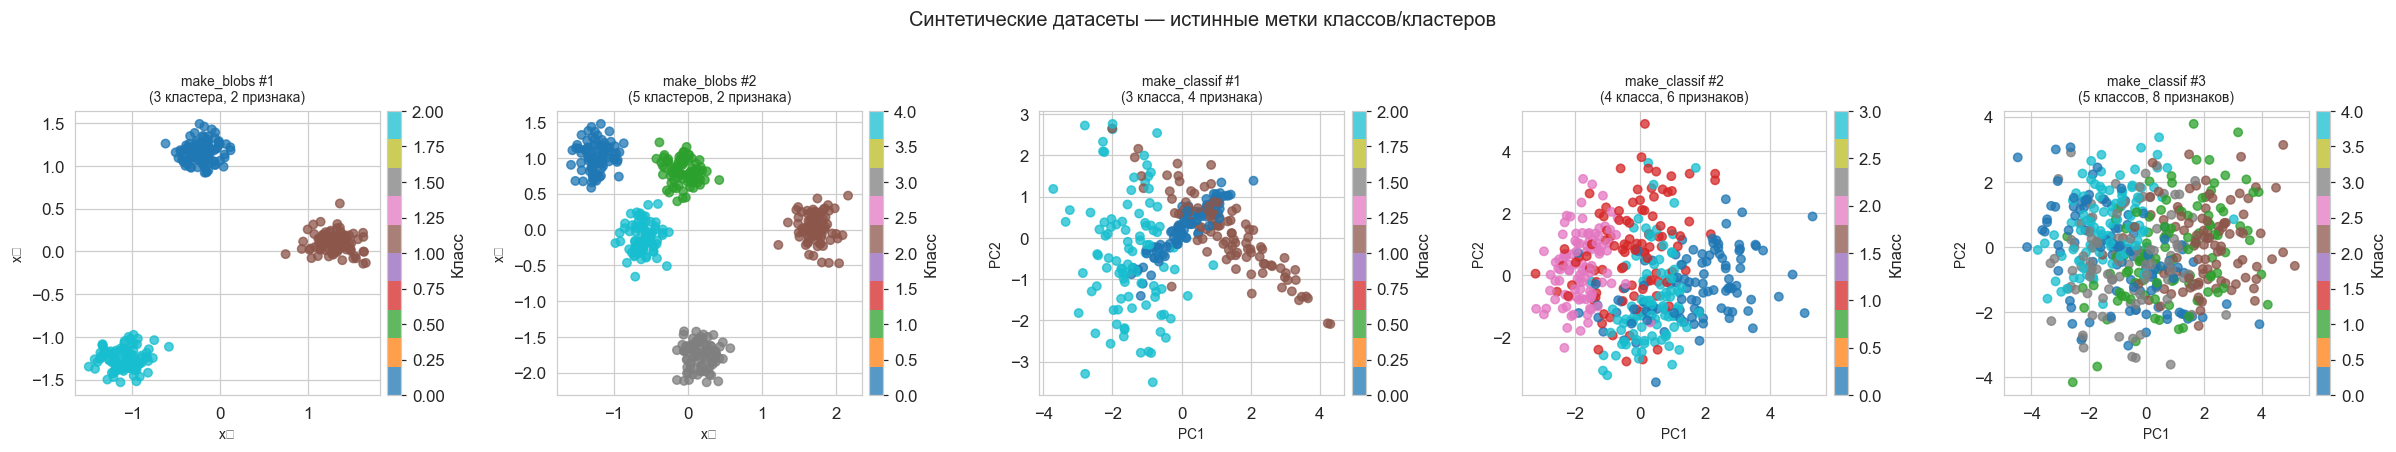

In [3]:
# Визуализация истинных меток всех 5 датасетов
fig, axes = plt.subplots(1, 5, figsize=(22, 4))

for ax, (name, X, y, desc) in zip(axes, datasets_info):
    X2 = to_2d(X)
    sc = ax.scatter(X2[:, 0], X2[:, 1], c=y, cmap=CMAP, alpha=0.75, s=30)
    ax.set_title(f"{name}\n({desc})", fontsize=9)
    ax.set_xlabel("PC1" if X.shape[1] > 2 else "x₁", fontsize=9)
    ax.set_ylabel("PC2" if X.shape[1] > 2 else "x₂", fontsize=9)
    plt.colorbar(sc, ax=ax, label='Класс', pad=0.02)

plt.suptitle("Синтетические датасеты — истинные метки классов/кластеров",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---
## 2. Загрузка и подготовка stud_end.csv

Датасет `stud_end.csv` — предобработанные данные о студентах (OHE, IQR-фильтрация).  
**Целевая переменная `Target` удаляется** перед кластеризацией — задача обучения без учителя.  
Метка сохраняется в `y_stud` для расчёта **внешних метрик** после кластеризации.

In [4]:
df_raw = pd.read_csv('../lab3/stud_end.csv')
# Конвертируем булевы столбцы в 0/1
df_raw = df_raw.replace({True: 1, False: 0})

print(f"Загружено: {df_raw.shape[0]} строк, {df_raw.shape[1]} столбцов")
print(f"Target: {df_raw['Target'].value_counts().to_dict()}")

# Кодируем Target (на случай строковых меток)
le = LabelEncoder()
y_stud = le.fit_transform(df_raw['Target'])
target_names = le.classes_

# Убираем Target из признаков
df_stud = df_raw.drop(columns=['Target'])
X_stud = df_stud.values.astype(float)

# Масштабирование
X_stud_sc = StandardScaler().fit_transform(X_stud)

print(f"\nПризнаки для кластеризации: {X_stud.shape[1]}")
print(f"Объектов: {X_stud.shape[0]}")
print(f"Метки (y_stud): {np.unique(y_stud)} → {target_names}")

Загружено: 3171 строк, 97 столбцов
Target: {2: 1946, 1: 654, 0: 571}

Признаки для кластеризации: 96
Объектов: 3171
Метки (y_stud): [0 1 2] → [0 1 2]


---
## 3. Подбор гиперпараметров

### 3.1 K-Means — метод локтя и график силуэтов (make_blobs #1)
Для выбора оптимального числа кластеров K используем два критерия:
- **Метод локтя** — ищем точку перегиба на графике WCSS
- **График силуэтов** — ищем максимум Silhouette Score

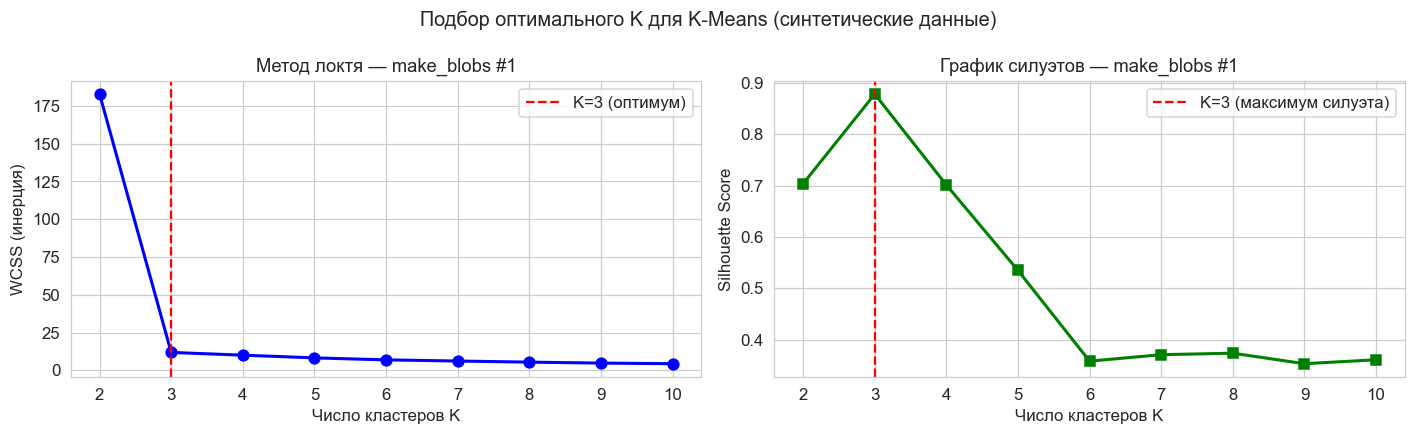

Оптимальное K: 3  (Silhouette = 0.8783)
Истинное число кластеров в make_blobs #1: 3


In [5]:
# Используем make_blobs #1 как эталонный датасет (наиболее чёткие кластеры)
X_syn = blob1_Xs
y_syn = blob1_y
K_range = range(2, 11)

wcss_list, sil_list = [], []
for k in K_range:
    km = KMeans(n_clusters=k, random_state=RS, n_init=10)
    lbs = km.fit_predict(X_syn)
    wcss_list.append(km.inertia_)
    sil_list.append(silhouette_score(X_syn, lbs))

K_SYN = K_range[sil_list.index(max(sil_list))]  # оптимальное K

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(K_range, wcss_list, 'bo-', lw=2, ms=7)
ax1.axvline(K_SYN, color='red', ls='--', label=f'K={K_SYN} (оптимум)')
ax1.set_xlabel('Число кластеров K')
ax1.set_ylabel('WCSS (инерция)')
ax1.set_title('Метод локтя — make_blobs #1')
ax1.legend()

ax2.plot(K_range, sil_list, 'gs-', lw=2, ms=7)
ax2.axvline(K_SYN, color='red', ls='--', label=f'K={K_SYN} (максимум силуэта)')
ax2.set_xlabel('Число кластеров K')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('График силуэтов — make_blobs #1')
ax2.legend()

plt.suptitle('Подбор оптимального K для K-Means (синтетические данные)', fontsize=13)
plt.tight_layout()
plt.show()

print(f"Оптимальное K: {K_SYN}  (Silhouette = {max(sil_list):.4f})")
print(f"Истинное число кластеров в make_blobs #1: {len(np.unique(y_syn))}")

### 3.2 Иерархическая кластеризация — дендрограмма

По дендрограмме определяем оптимальное K: **разрезаем там, где вертикальные линии наиболее длинные** (максимальное расстояние между объединениями).

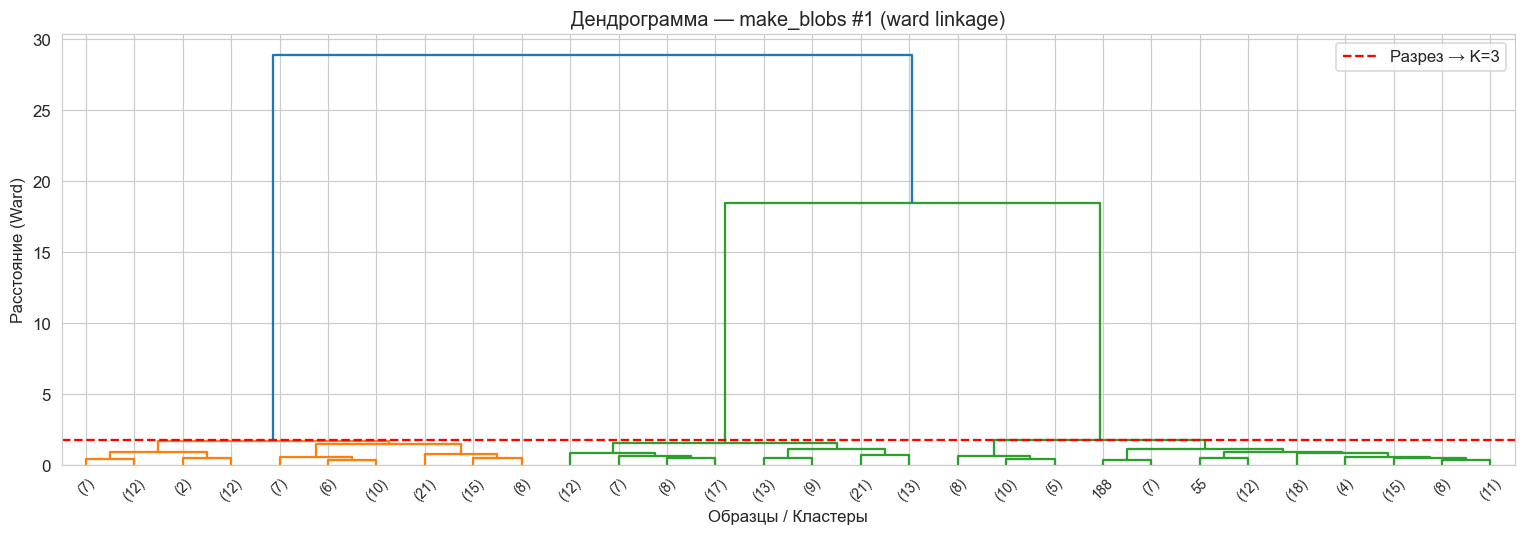

Рекомендуемый K = 3 кластера (линия разреза на уровне 1.74)


In [6]:
fig, ax = plt.subplots(figsize=(14, 5))
linkage_matrix = sch.linkage(X_syn, method='ward')
sch.dendrogram(linkage_matrix, ax=ax, truncate_mode='lastp', p=30,
               leaf_rotation=45, leaf_font_size=9)
ax.set_title('Дендрограмма — make_blobs #1 (ward linkage)', fontsize=13)
ax.set_xlabel('Образцы / Кластеры')
ax.set_ylabel('Расстояние (Ward)')
# Горизонтальная линия разреза на оптимальном уровне
last_merges = linkage_matrix[-10:, 2]
cut_level = (last_merges[-K_SYN] + last_merges[-(K_SYN+1)]) / 2
ax.axhline(y=cut_level, color='red', ls='--', lw=1.5, label=f'Разрез → K={K_SYN}')
ax.legend()
plt.tight_layout()
plt.show()
print(f"Рекомендуемый K = {K_SYN} кластера (линия разреза на уровне {cut_level:.2f})")

### 3.3 DBSCAN — k-distance graph для подбора eps

Строим график расстояний до 5-го соседа. **Точка перегиба (локоть)** указывает на оптимальное значение `eps`.

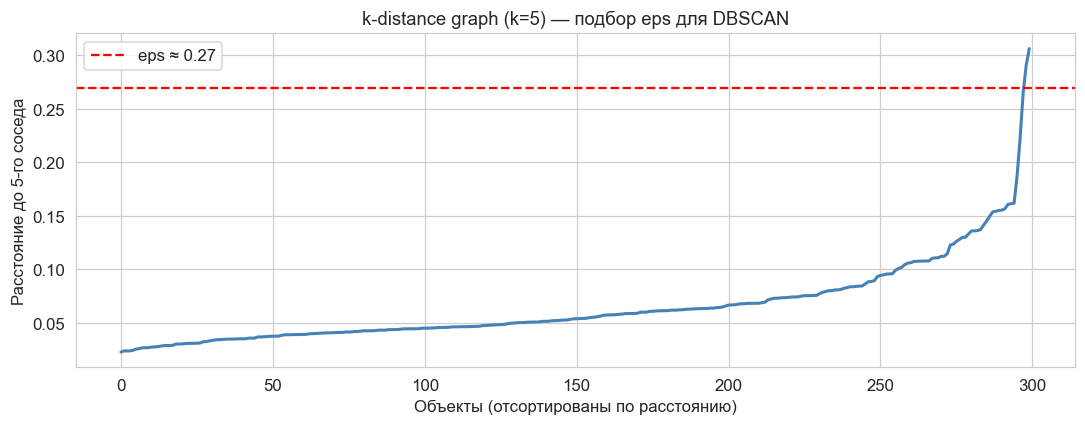

Рекомендуемое eps = 0.27,  min_samples = 5


In [7]:
MIN_SAMPLES = 5
nn = NearestNeighbors(n_neighbors=MIN_SAMPLES)
nn.fit(X_syn)
distances, _ = nn.kneighbors(X_syn)
dist_sorted = np.sort(distances[:, -1])

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(dist_sorted, lw=2, color='steelblue')
ax.set_title(f'k-distance graph (k={MIN_SAMPLES}) — подбор eps для DBSCAN')
ax.set_xlabel('Объекты (отсортированы по расстоянию)')
ax.set_ylabel(f'Расстояние до {MIN_SAMPLES}-го соседа')

# Автоматически находим "локоть" методом максимального изменения производной
diffs = np.diff(dist_sorted)
elbow_idx = np.argmax(diffs) + 1
EPS_SYN = round(float(dist_sorted[elbow_idx]), 2)
ax.axhline(EPS_SYN, color='red', ls='--', lw=1.5, label=f'eps ≈ {EPS_SYN}')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Рекомендуемое eps = {EPS_SYN},  min_samples = {MIN_SAMPLES}")

### 3.4 EM-алгоритм (GaussianMixture) — подбор числа компонент по BIC

**BIC** (Bayesian Information Criterion) — чем меньше, тем лучше. Ищем минимум.

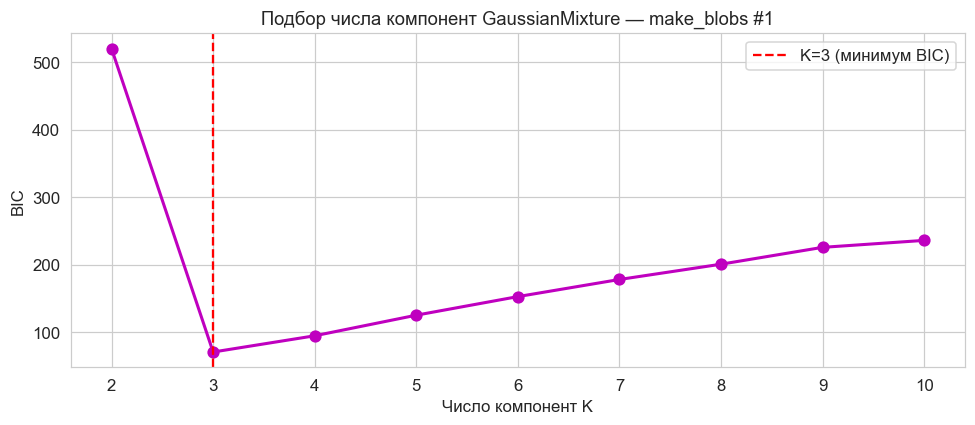

Оптимальное K для GaussianMixture: 3  (BIC = 70.4)


In [8]:
bic_list = []
for k in K_range:
    gm = GaussianMixture(n_components=k, random_state=RS, n_init=5)
    gm.fit(X_syn)
    bic_list.append(gm.bic(X_syn))

K_GM_SYN = K_range[bic_list.index(min(bic_list))]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(K_range, bic_list, 'mo-', lw=2, ms=7)
ax.axvline(K_GM_SYN, color='red', ls='--', lw=1.5, label=f'K={K_GM_SYN} (минимум BIC)')
ax.set_xlabel('Число компонент K')
ax.set_ylabel('BIC')
ax.set_title('Подбор числа компонент GaussianMixture — make_blobs #1')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Оптимальное K для GaussianMixture: {K_GM_SYN}  (BIC = {min(bic_list):.1f})")

---
## 4. Кластеризация синтетических данных (make_blobs #1)

Применяем все 5 алгоритмов к датасету `make_blobs #1` (3 кластера, 2D).  
Результаты кластеризации сохраняются для последующей оценки метриками.

### 4.1 K-Means (sklearn)

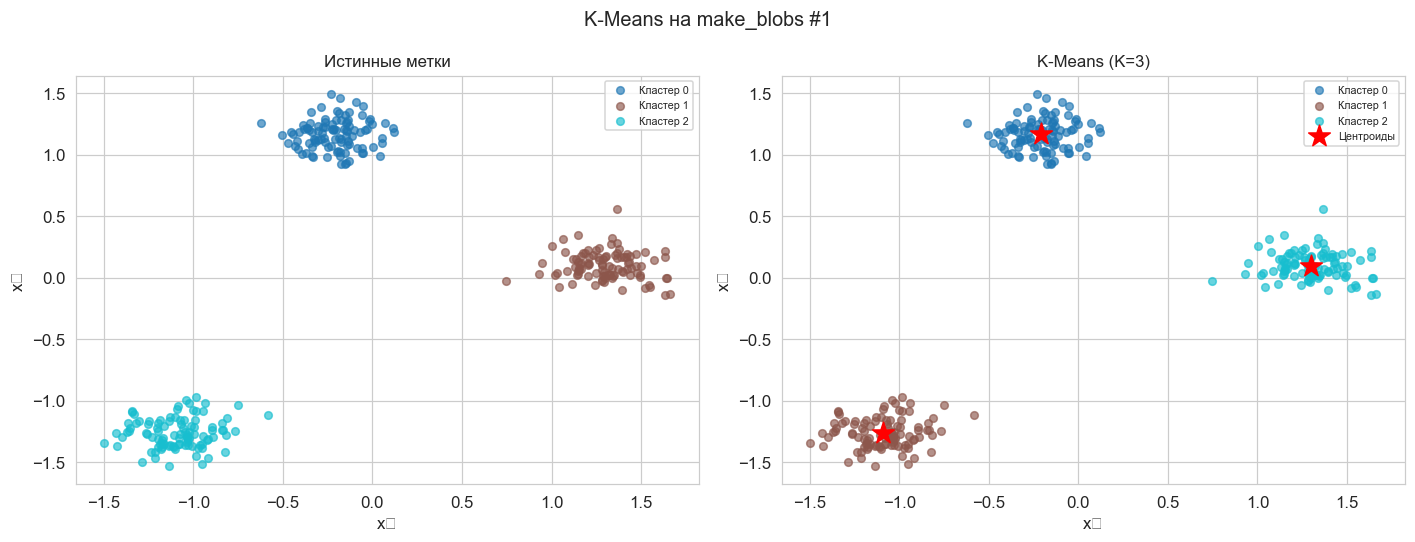

K-Means | Silhouette=0.8783  DB=0.1692  ARI=1.0000  NMI=1.0000
WCSS (инерция) = 11.88
Качество кластеров по виду: кластеры чётко разделены, центроиды точно в центре каждой группы.


In [9]:
km_syn = KMeans(n_clusters=K_SYN, random_state=RS, n_init=10)
labels_km_syn = km_syn.fit_predict(X_syn)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
plot_clusters(ax1, X_syn, y_syn,    'Истинные метки',         centers=None)
plot_clusters(ax2, X_syn, labels_km_syn, f'K-Means (K={K_SYN})', centers=km_syn.cluster_centers_)
plt.suptitle('K-Means на make_blobs #1', fontsize=13)
plt.tight_layout()
plt.show()

sil, db, ari, nmi = safe_metrics(X_syn, labels_km_syn, y_syn)
print(f"K-Means | Silhouette={sil:.4f}  DB={db:.4f}  ARI={ari:.4f}  NMI={nmi:.4f}")
print(f"WCSS (инерция) = {km_syn.inertia_:.2f}")
print("Качество кластеров по виду: кластеры чётко разделены, центроиды точно в центре каждой группы.")

### 4.2 Иерархическая кластеризация (AgglomerativeClustering, ward)

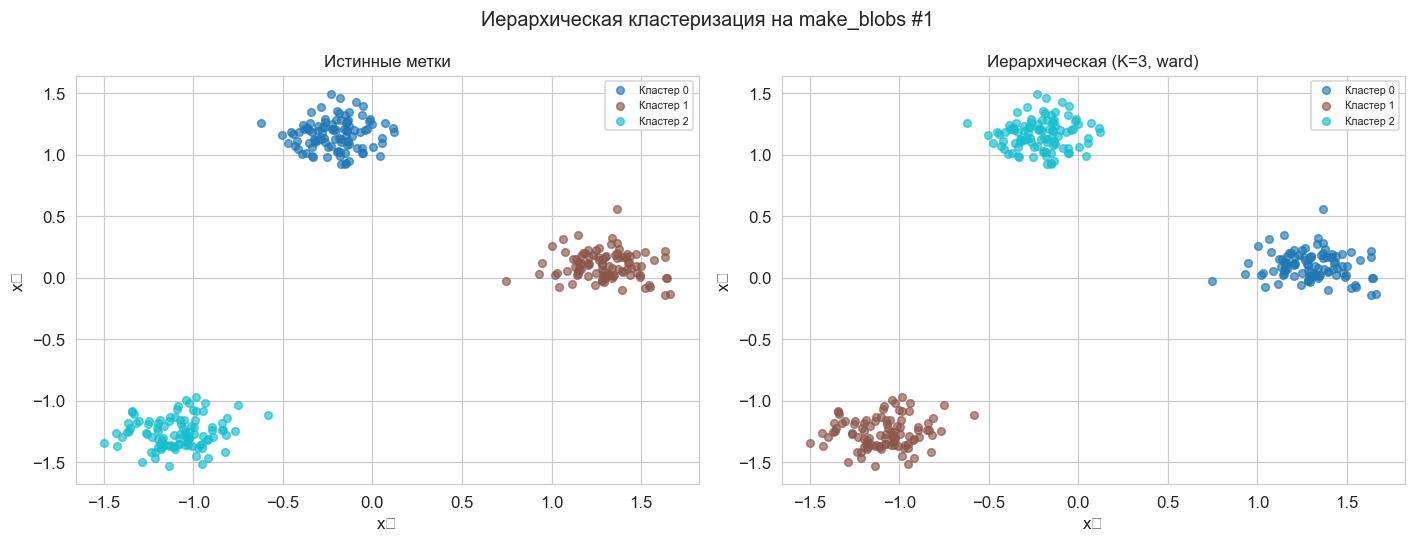

Hierarchical | Silhouette=0.8783  DB=0.1692  ARI=1.0000  NMI=1.0000
Качество кластеров по виду: результат практически идентичен K-Means на сферических кластерах.


In [10]:
hc_syn = AgglomerativeClustering(n_clusters=K_SYN, metric='euclidean', linkage='ward')
labels_hc_syn = hc_syn.fit_predict(X_syn)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
plot_clusters(ax1, X_syn, y_syn,        'Истинные метки')
plot_clusters(ax2, X_syn, labels_hc_syn, f'Иерархическая (K={K_SYN}, ward)')
plt.suptitle('Иерархическая кластеризация на make_blobs #1', fontsize=13)
plt.tight_layout()
plt.show()

sil, db, ari, nmi = safe_metrics(X_syn, labels_hc_syn, y_syn)
print(f"Hierarchical | Silhouette={sil:.4f}  DB={db:.4f}  ARI={ari:.4f}  NMI={nmi:.4f}")
print("Качество кластеров по виду: результат практически идентичен K-Means на сферических кластерах.")

### 4.3 DBSCAN

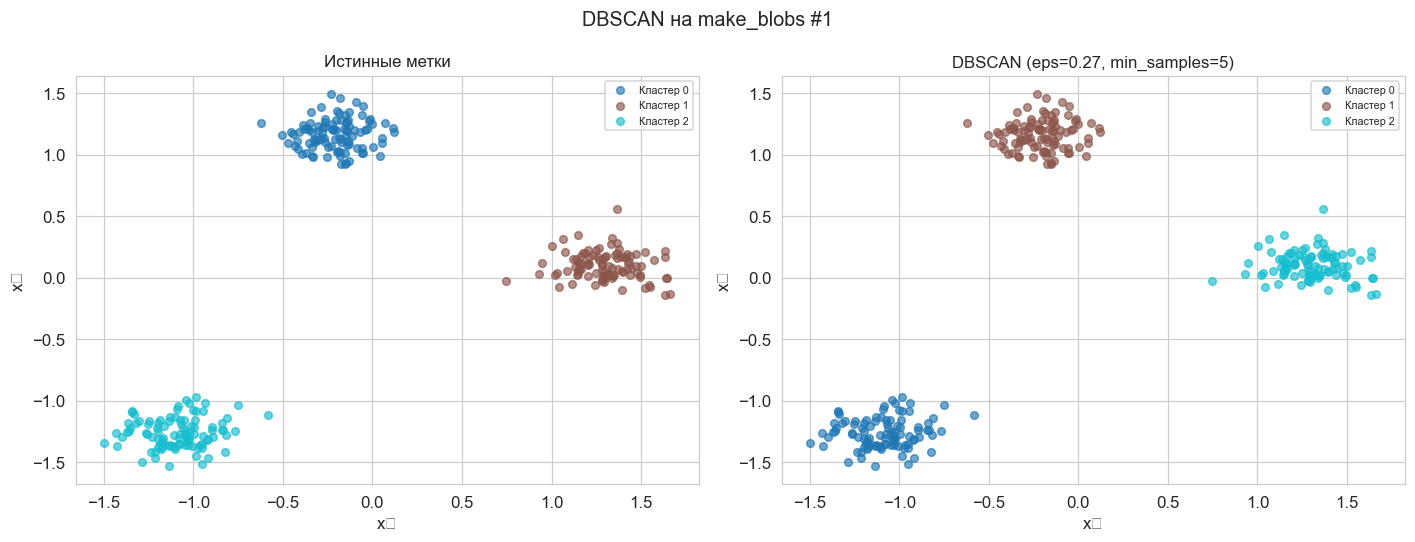

Найдено кластеров: 3,  шумовых точек: 0
DBSCAN | Silhouette=0.8783  DB=0.1692  ARI=1.0000  NMI=1.0000
Качество по виду: хорошо выделяет плотные группы, шумовые точки окрашены в чёрный.


In [11]:
db_syn = DBSCAN(eps=EPS_SYN, min_samples=MIN_SAMPLES)
labels_db_syn = db_syn.fit_predict(X_syn)

n_clusters_db = len(set(labels_db_syn)) - (1 if -1 in labels_db_syn else 0)
n_noise_db    = list(labels_db_syn).count(-1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
plot_clusters(ax1, X_syn, y_syn,       'Истинные метки')
plot_clusters(ax2, X_syn, labels_db_syn, f'DBSCAN (eps={EPS_SYN}, min_samples={MIN_SAMPLES})')
plt.suptitle('DBSCAN на make_blobs #1', fontsize=13)
plt.tight_layout()
plt.show()

print(f"Найдено кластеров: {n_clusters_db},  шумовых точек: {n_noise_db}")
sil, db, ari, nmi = safe_metrics(X_syn, labels_db_syn, y_syn)
sil_str = f"{sil:.4f}" if sil else "—"
db_str  = f"{db:.4f}"  if db  else "—"
print(f"DBSCAN | Silhouette={sil_str}  DB={db_str}  ARI={ari:.4f}  NMI={nmi:.4f}")
print("Качество по виду: хорошо выделяет плотные группы, шумовые точки окрашены в чёрный.")

### 4.4 EM-алгоритм (GaussianMixture)

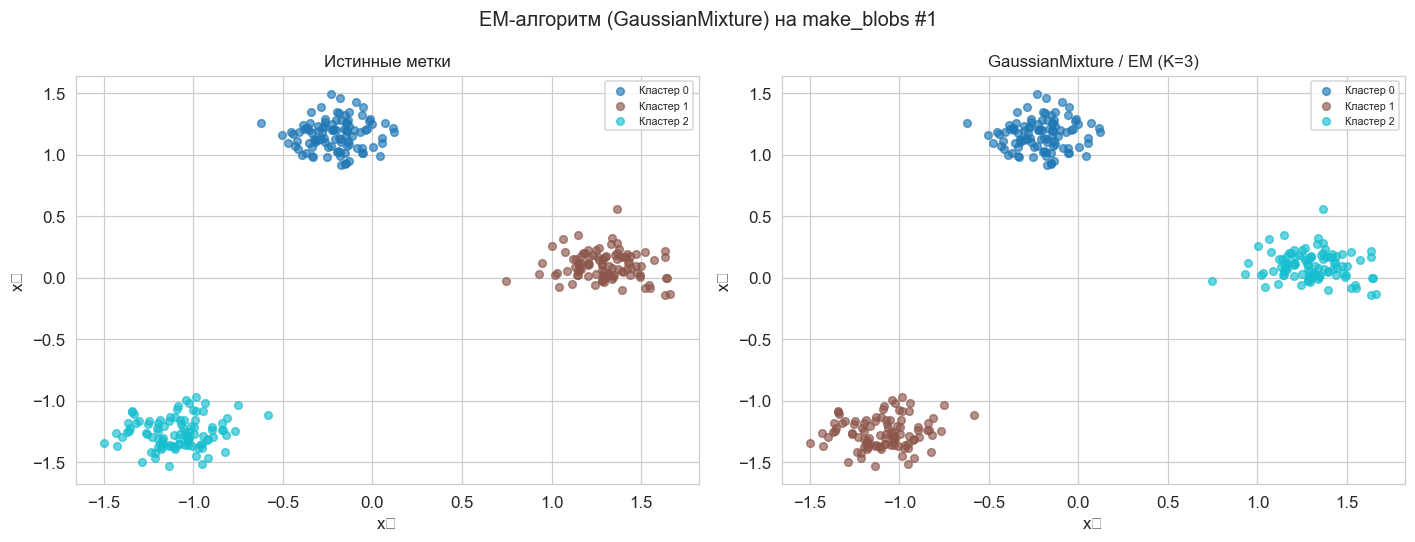

GaussianMixture | Silhouette=0.8783  DB=0.1692  ARI=1.0000  NMI=1.0000
Качество по виду: мягкое вероятностное присвоение. На сферических кластерах совпадает с K-Means.


In [12]:
gm_syn = GaussianMixture(n_components=K_GM_SYN, random_state=RS, n_init=5)
labels_gm_syn = gm_syn.fit_predict(X_syn)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
plot_clusters(ax1, X_syn, y_syn,       'Истинные метки')
plot_clusters(ax2, X_syn, labels_gm_syn, f'GaussianMixture / EM (K={K_GM_SYN})')
plt.suptitle('EM-алгоритм (GaussianMixture) на make_blobs #1', fontsize=13)
plt.tight_layout()
plt.show()

sil, db, ari, nmi = safe_metrics(X_syn, labels_gm_syn, y_syn)
print(f"GaussianMixture | Silhouette={sil:.4f}  DB={db:.4f}  ARI={ari:.4f}  NMI={nmi:.4f}")
print("Качество по виду: мягкое вероятностное присвоение. На сферических кластерах совпадает с K-Means.")

### 4.5 Affinity Propagation

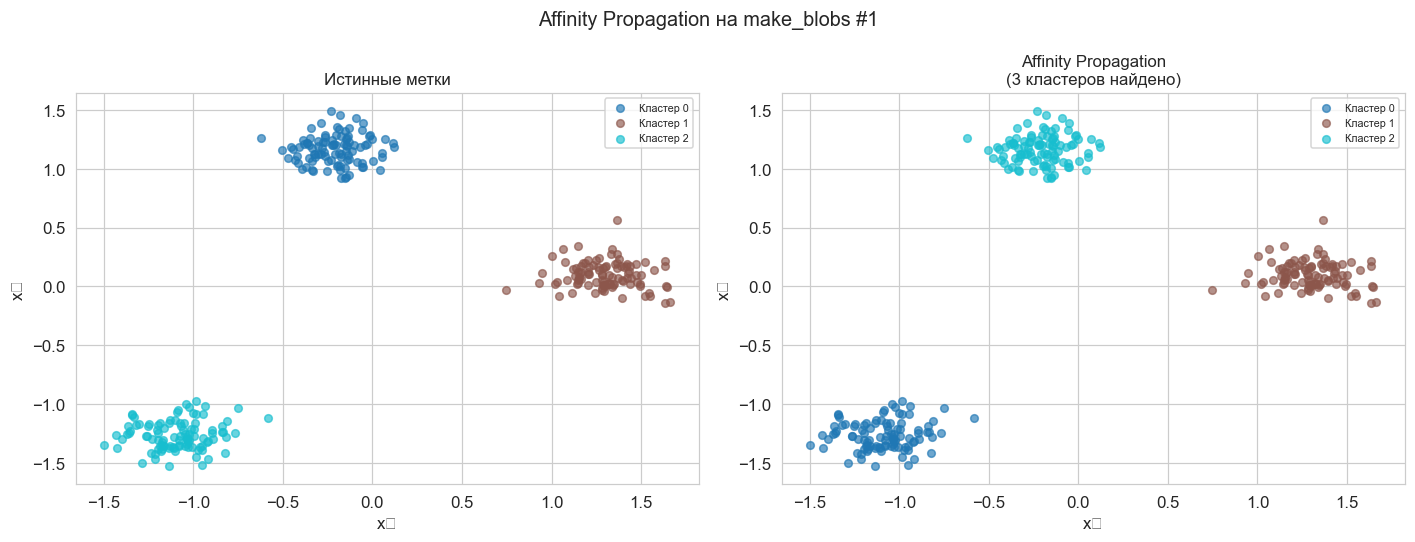

Найдено кластеров: 3
AffinityProp | Silhouette=0.8783  DB=0.1692  ARI=1.0000  NMI=1.0000
Качество по виду: AP автоматически определяет K. Иногда дробит кластеры — зависит от damping.


In [13]:
ap_syn = AffinityPropagation(damping=0.7, random_state=RS, max_iter=300)
labels_ap_syn = ap_syn.fit_predict(X_syn)
n_clusters_ap = len(ap_syn.cluster_centers_indices_)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
plot_clusters(ax1, X_syn, y_syn,      'Истинные метки')
plot_clusters(ax2, X_syn, labels_ap_syn, f'Affinity Propagation\n({n_clusters_ap} кластеров найдено)')
plt.suptitle('Affinity Propagation на make_blobs #1', fontsize=13)
plt.tight_layout()
plt.show()

sil, db, ari, nmi = safe_metrics(X_syn, labels_ap_syn, y_syn)
print(f"Найдено кластеров: {n_clusters_ap}")
print(f"AffinityProp | Silhouette={sil:.4f}  DB={db:.4f}  ARI={ari:.4f}  NMI={nmi:.4f}")
print("Качество по виду: AP автоматически определяет K. Иногда дробит кластеры — зависит от damping.")

---
### 4.6 Все алгоритмы на всех 5 синтетических датасетах

Прогоняем все 5 алгоритмов на каждом из 5 датасетов.  
K подбирается автоматически через силуэт, eps для DBSCAN — через k-distance elbow.

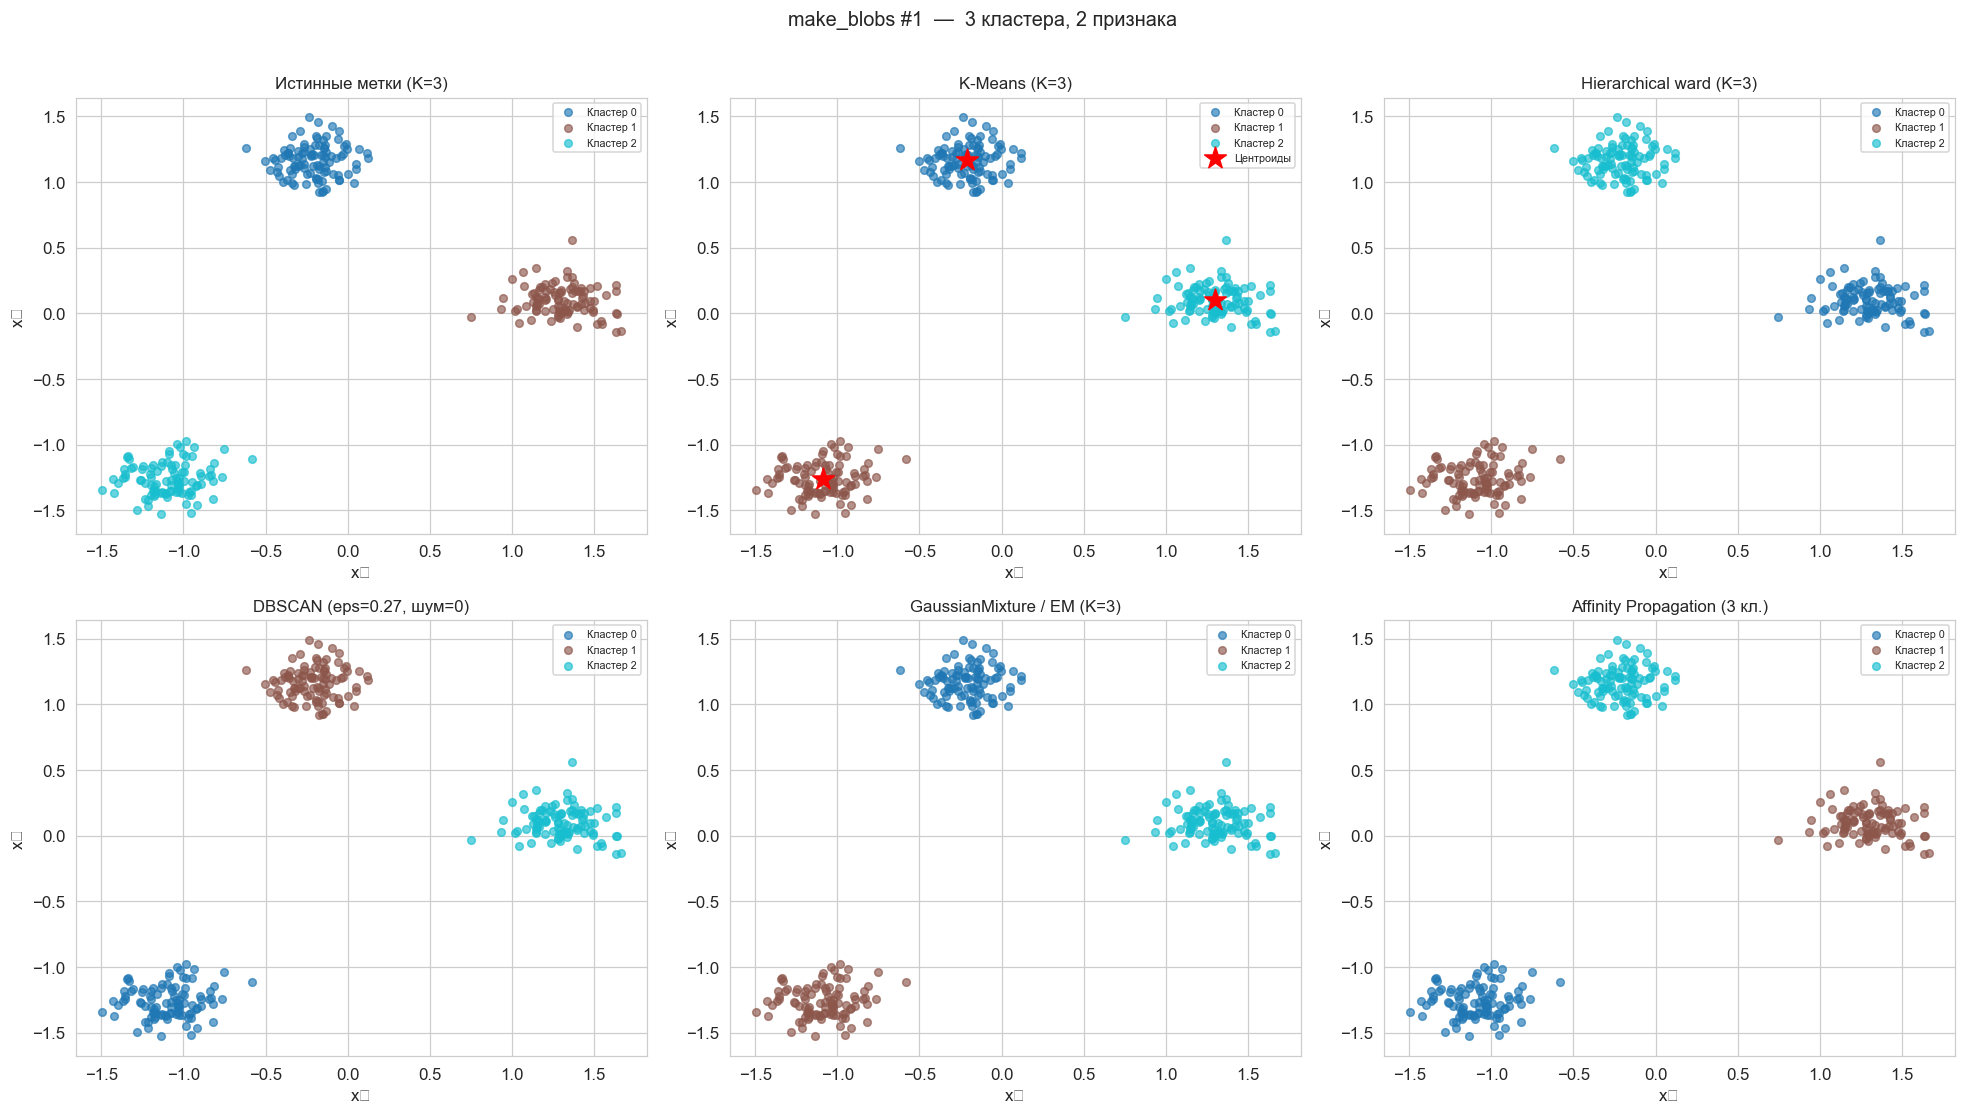

✓ make_blobs #1        | K=3  eps=0.27  AP нашёл 3 кластеров


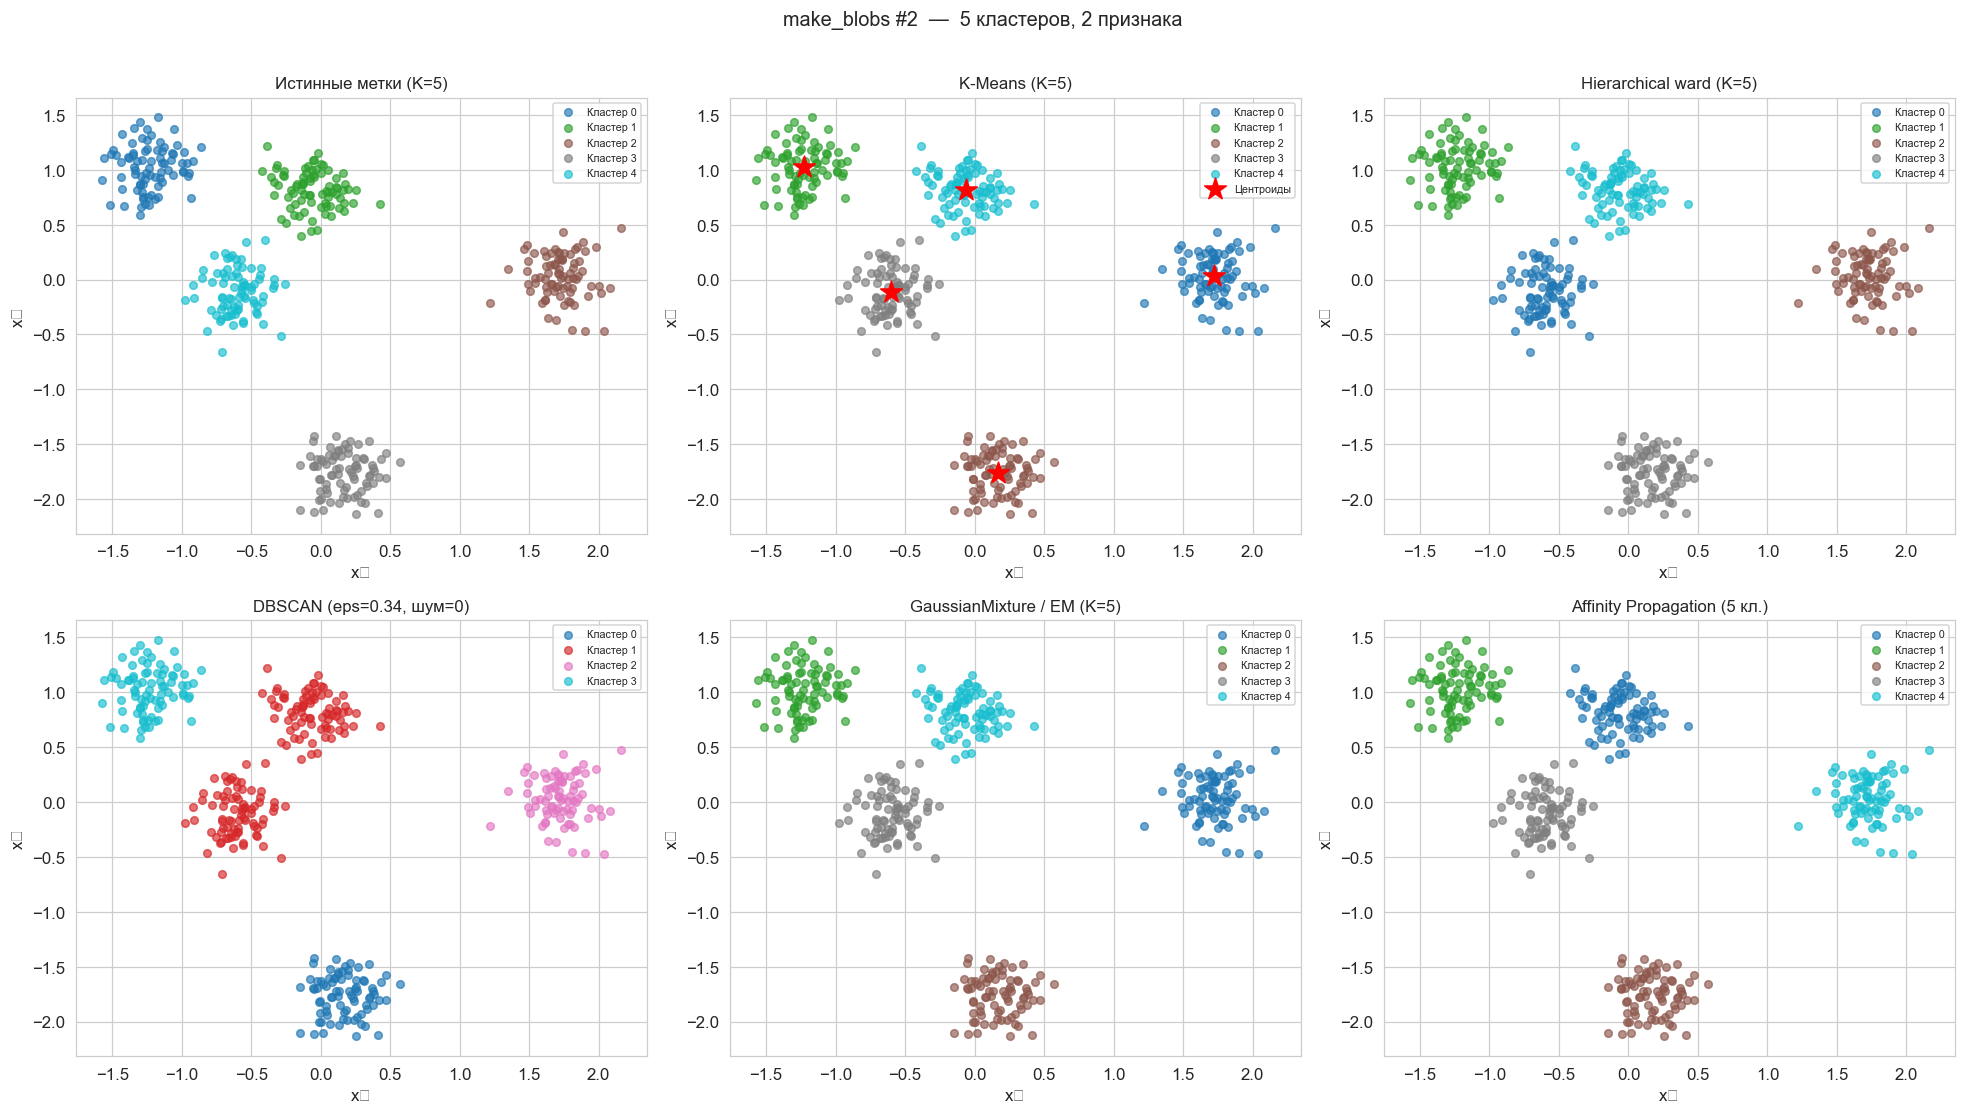

✓ make_blobs #2        | K=5  eps=0.34  AP нашёл 5 кластеров


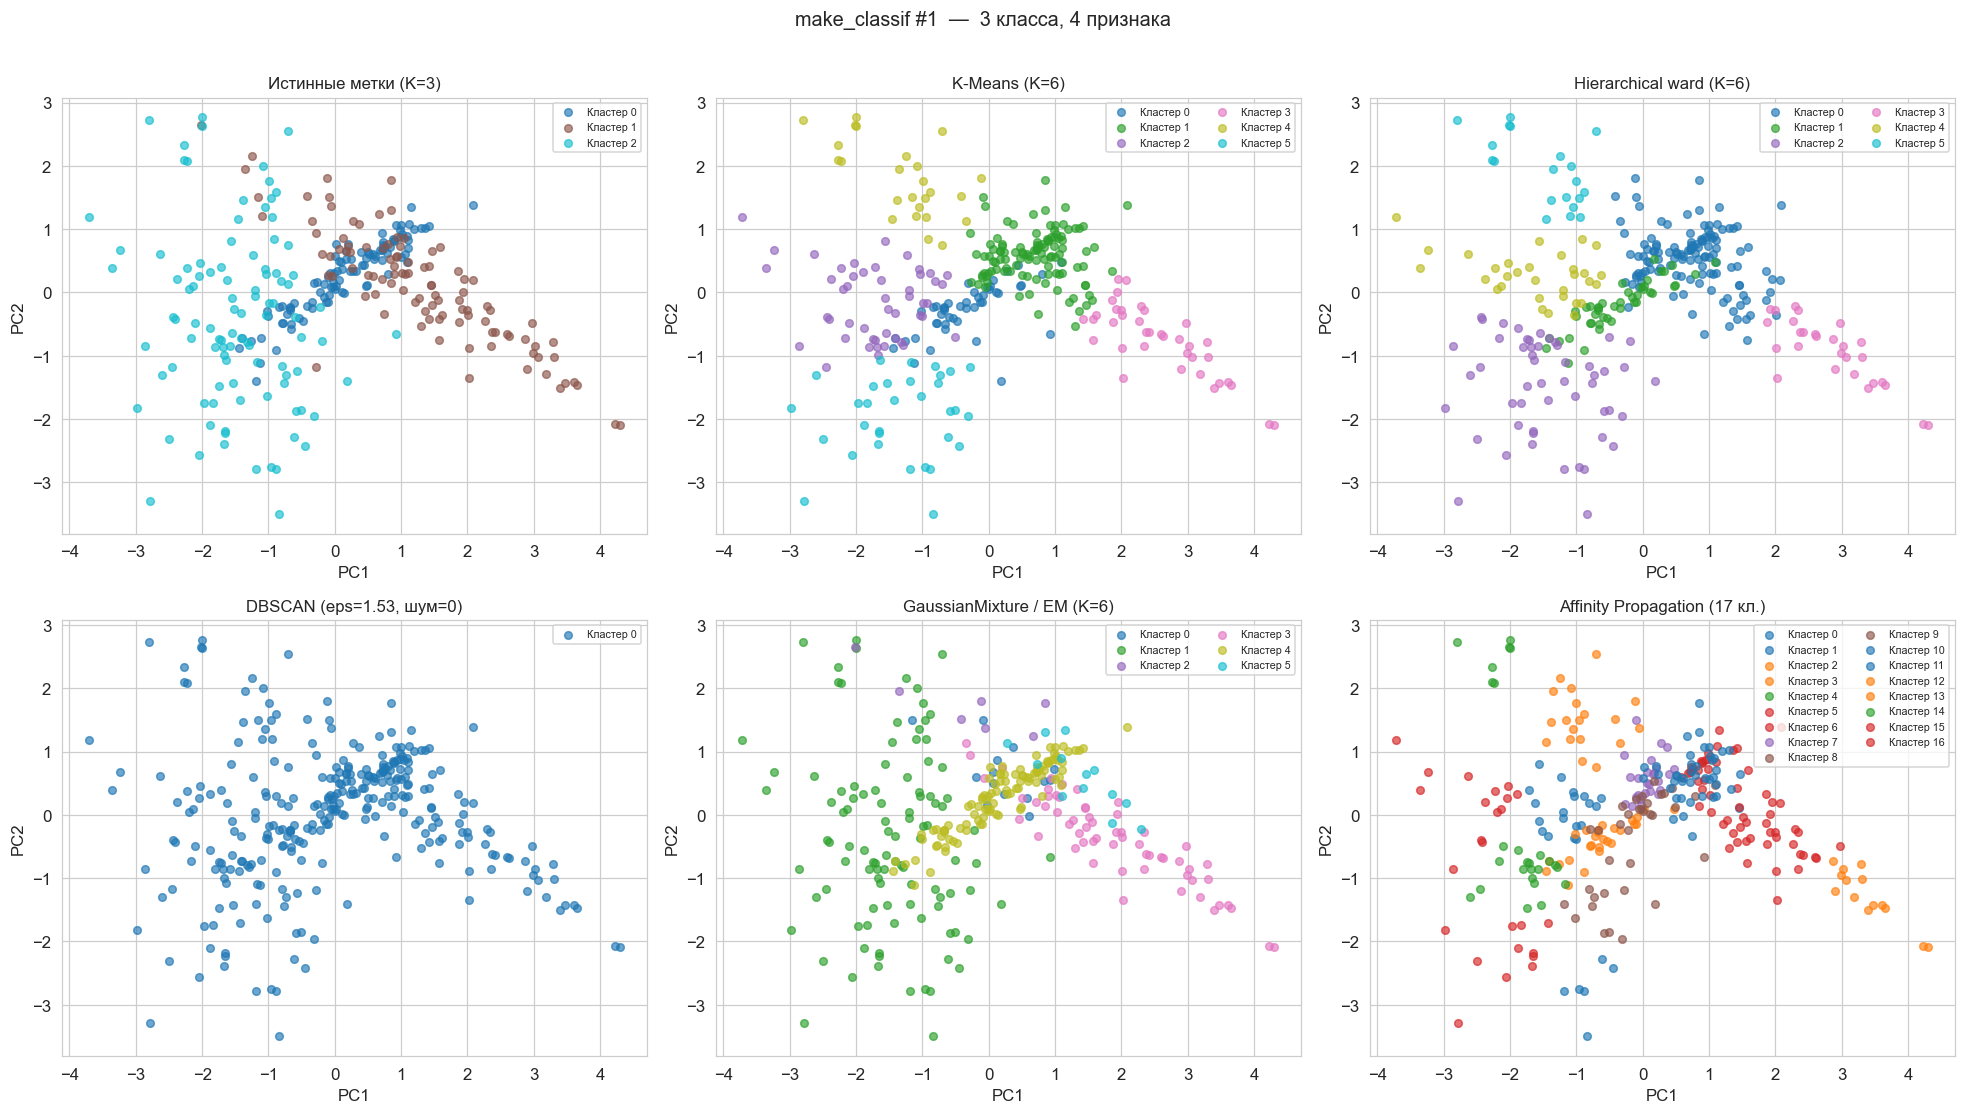

✓ make_classif #1      | K=6  eps=1.53  AP нашёл 17 кластеров


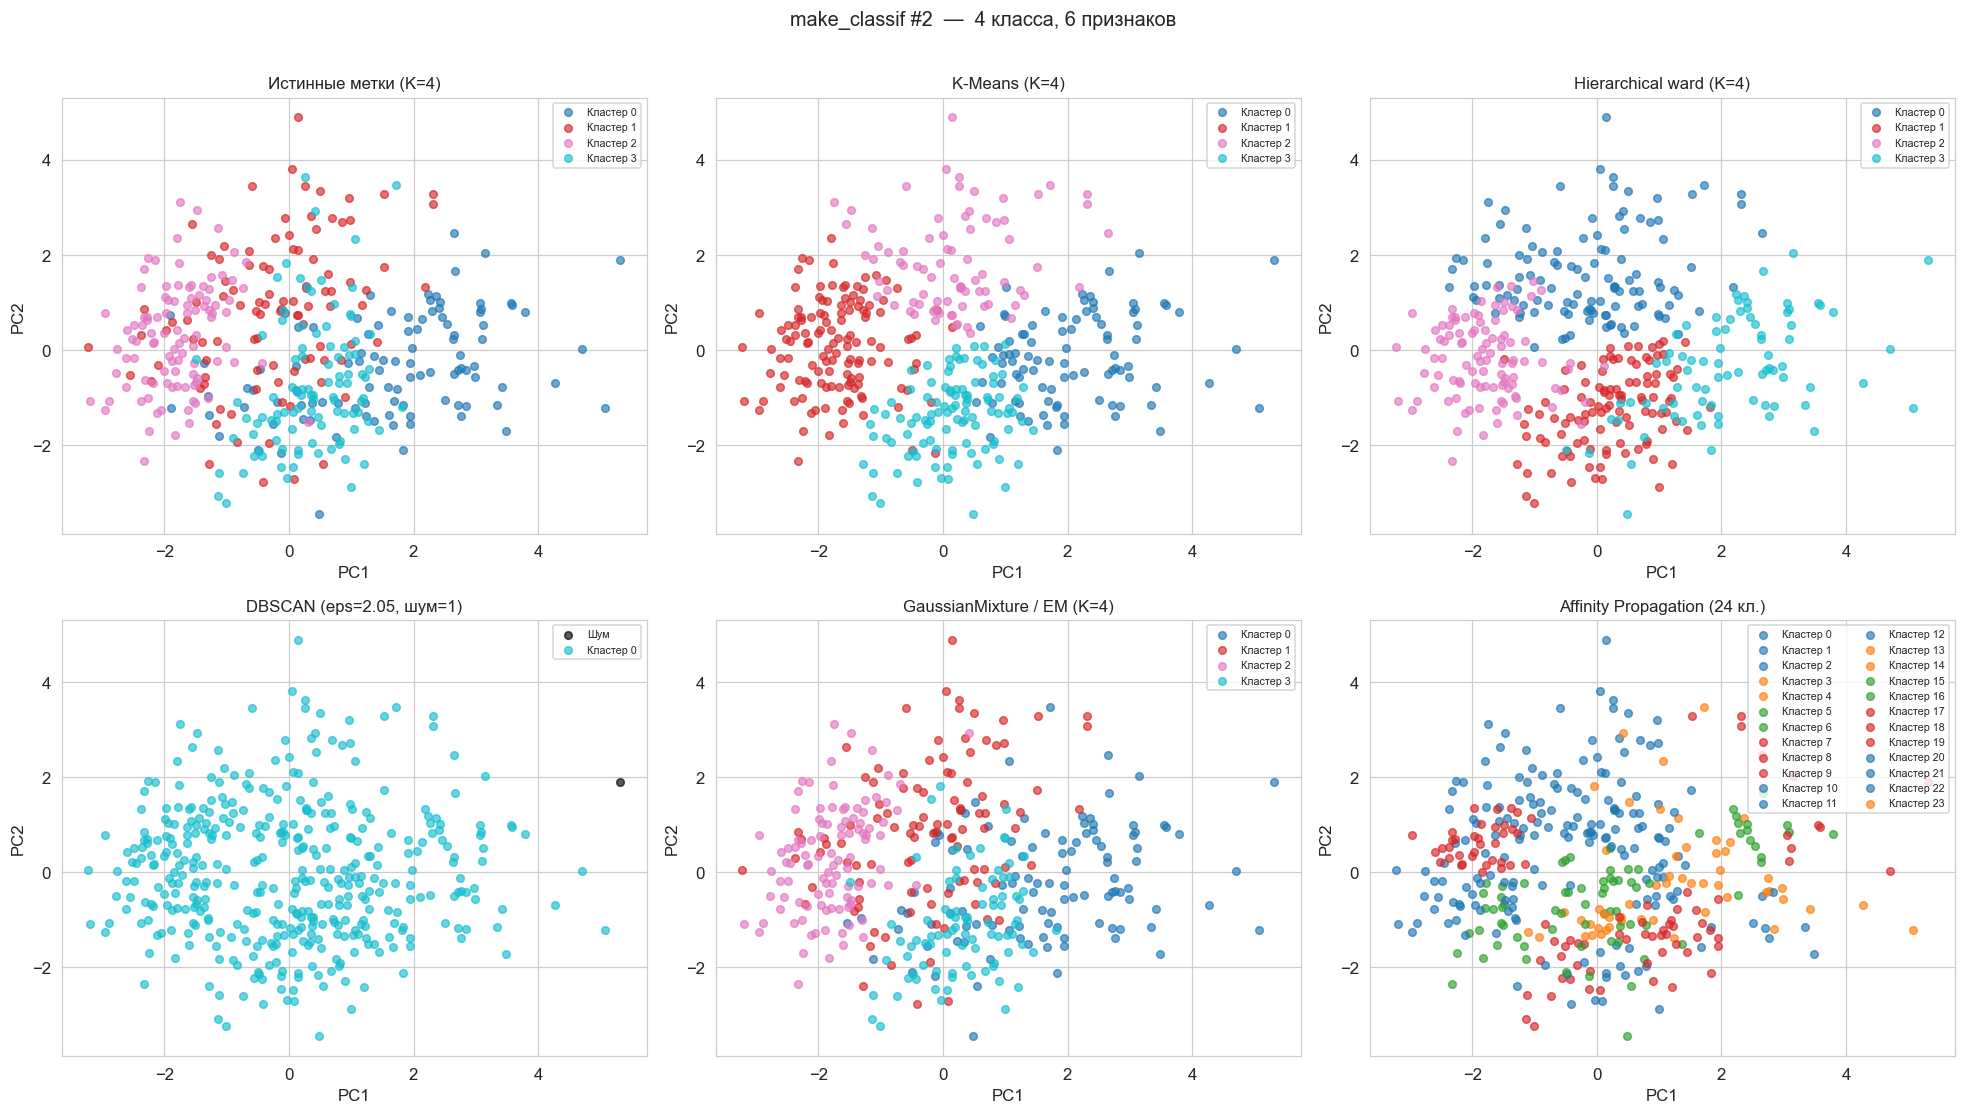

✓ make_classif #2      | K=4  eps=2.05  AP нашёл 24 кластеров


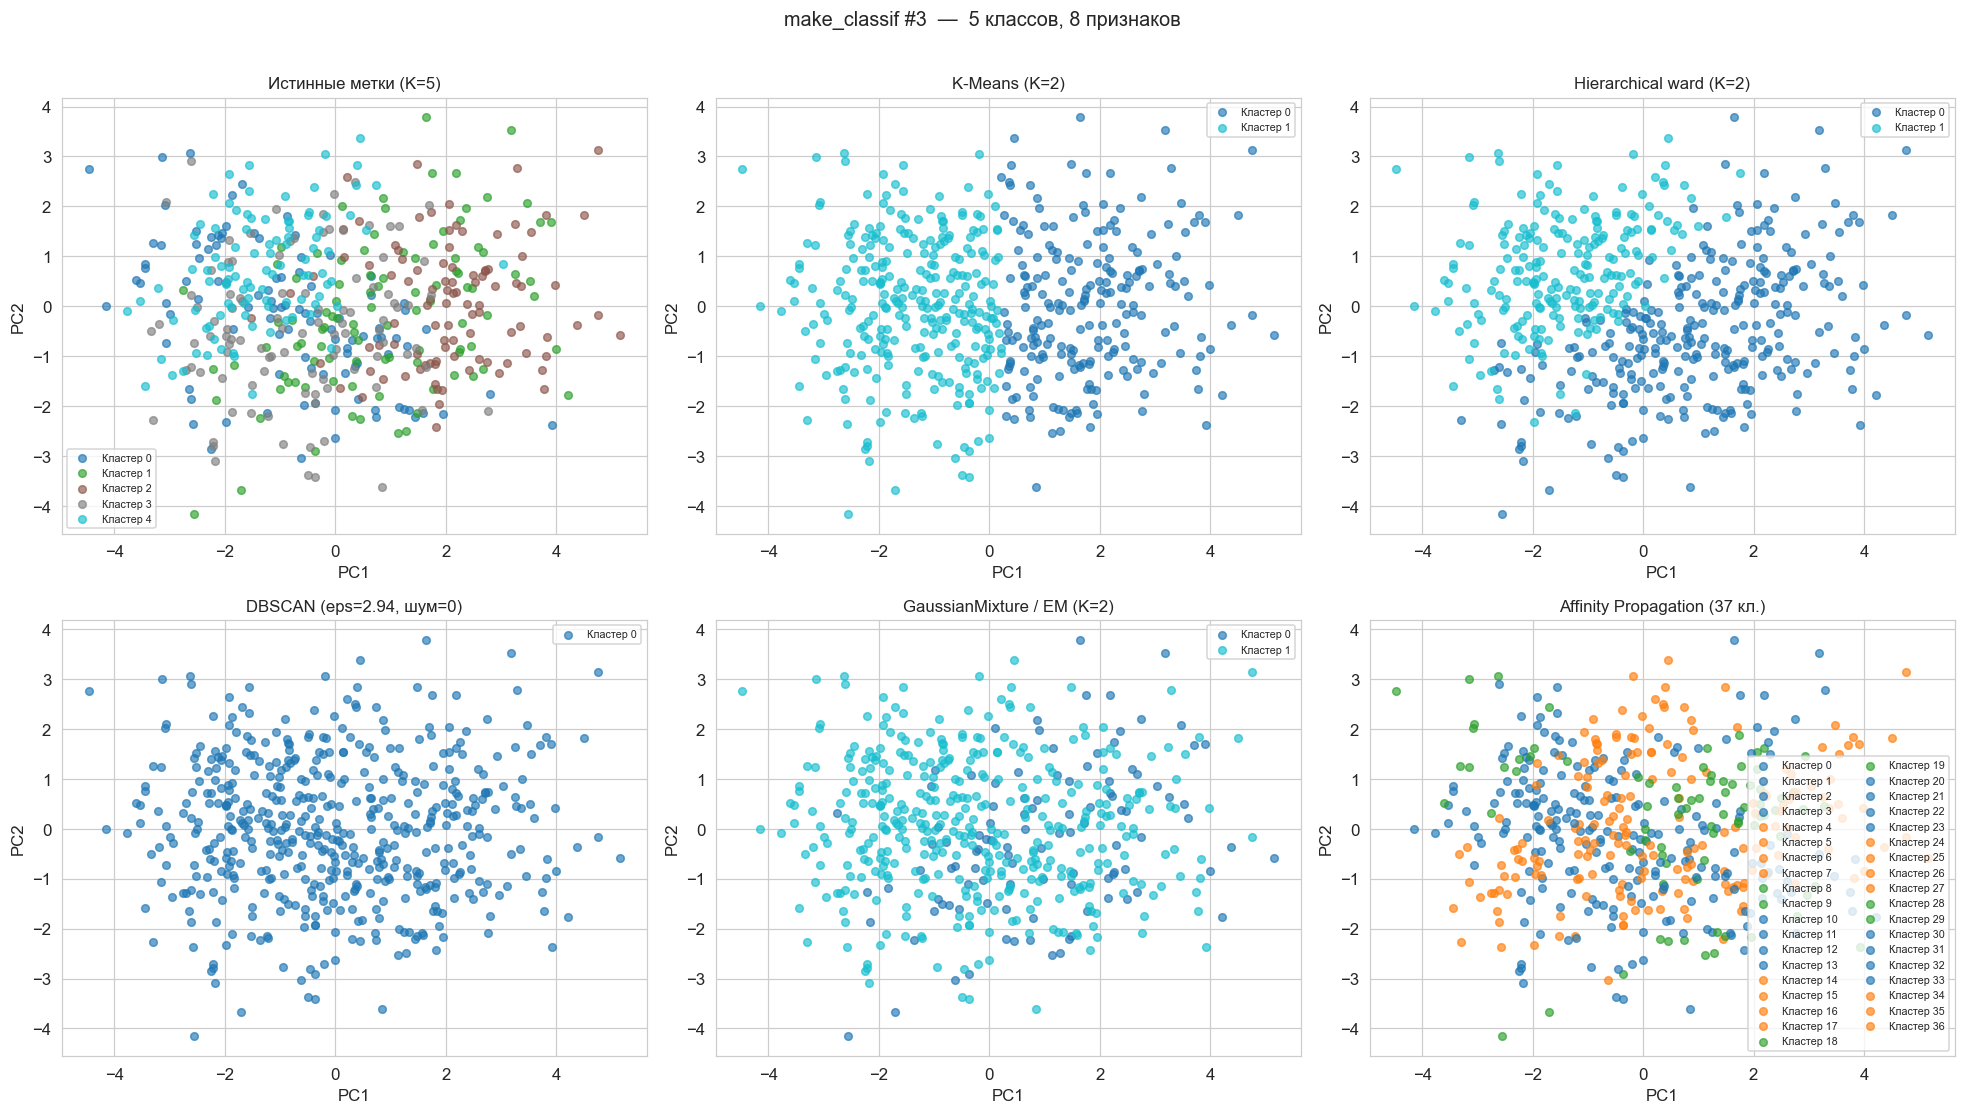

✓ make_classif #3      | K=2  eps=2.94  AP нашёл 37 кластеров

=== Все алгоритмы × все 5 синтетических датасетов ===


K (авто) Silhouette ↑ Davies-Bouldin ↓  \
Датасет         Алгоритм                                                     
make_blobs #1   K-Means                    3       0.8783           0.1692   
                Hierarchical (ward)        3       0.8783           0.1692   
                DBSCAN                     —       0.8783           0.1692   
                GaussianMixture/EM         3       0.8783           0.1692   
                AffinityPropagation        —       0.8783           0.1692   
make_blobs #2   K-Means                    5       0.7587           0.3325   
                Hierarchical (ward)        5       0.7587           0.3325   
                DBSCAN                     —       0.6620           0.5406   
                GaussianMixture/EM         5       0.7587           0.3325   
                AffinityPropagation        —       0.7587           0.3325   
make_classif #1 K-Means                    6       0.4044           0.8443   
                Hierarchical (ward)        6       0.3807           0.8731   
                DBSCAN                     —            —                —   
                GaussianMixture/EM         6      -0.0063           1.7563   
                AffinityPropagation        —       0.3201           0.8837   
make_classif #2 K-Means                    4       0.2965           1.1103   
                Hierarchical (ward)        4       0.2650           1.2035   
                DBSCAN                     —            —                —   
                GaussianMixture/EM         4       0.1678           1.6127   
                AffinityPropagation        —       0.2575           1.0866   
make_classif #3 K-Means                    2       0.2712           1.3939   
                Hierarchical (ward)        2       0.2212           1.6116   
                DBSCAN                     —            —                —   
                GaussianMixture/EM         2       0.0742           3.0006   
                AffinityPropagation        —       0.1926           1.1845   

                                       ARI ↑   NMI ↑  
Датасет         Алгоритм                              
make_blobs #1   K-Means               1.0000  1.0000  
                Hierarchical (ward)   1.0000  1.0000  
                DBSCAN                1.0000  1.0000  
                GaussianMixture/EM    1.0000  1.0000  
                AffinityPropagation   1.0000  1.0000  
make_blobs #2   K-Means               1.0000  1.0000  
                Hierarchical (ward)   1.0000  1.0000  
                DBSCAN                0.7809  0.9057  
                GaussianMixture/EM    1.0000  1.0000  
                AffinityPropagation   1.0000  1.0000  
make_classif #1 K-Means               0.3300  0.5010  
                Hierarchical (ward)   0.3440  0.5194  
                DBSCAN                0.0000  0.0000  
                GaussianMixture/EM    0.7185  0.6814  
                AffinityPropagation   0.1540  0.3965  
make_classif #2 K-Means               0.4183  0.4247  
                Hierarchical (ward)   0.4067  0.4609  
                DBSCAN               -0.0000  0.0049  
                GaussianMixture/EM    0.8356  0.7947  
                AffinityPropagation   0.1572  0.4259  
make_classif #3 K-Means               0.1477  0.1923  
                Hierarchical (ward)   0.1705  0.2351  
                DBSCAN                0.0000  0.0000  
                GaussianMixture/EM    0.1881  0.3769  
                AffinityPropagation   0.1121  0.4059

In [14]:
_fmt = lambda v: f"{v:.4f}" if v is not None else "—"   # локальный хелпер

all_syn_rows = []

for ds_name, X_ds, y_ds, ds_desc in datasets_info:
    n_true_k = len(np.unique(y_ds))

    # ── Подбор K через силуэт ────────────────────────────────────────────
    k_range_ds = range(2, min(10, len(X_ds) // 20 + 2))
    sil_scores = [
        silhouette_score(X_ds, KMeans(n_clusters=k, random_state=RS, n_init=10).fit_predict(X_ds))
        for k in k_range_ds
    ]
    K_ds = list(k_range_ds)[int(np.argmax(sil_scores))]

    # ── Подбор eps для DBSCAN через k-distance ───────────────────────────
    nn_ds    = NearestNeighbors(n_neighbors=MIN_SAMPLES).fit(X_ds)
    d_ds, _  = nn_ds.kneighbors(X_ds)
    d_sorted = np.sort(d_ds[:, -1])
    elbow_i  = int(np.argmax(np.diff(d_sorted))) + 1
    eps_ds   = round(float(d_sorted[elbow_i]), 2)

    # ── Обучение алгоритмов ──────────────────────────────────────────────
    km_ds  = KMeans(n_clusters=K_ds, random_state=RS, n_init=10)
    lbs_km = km_ds.fit_predict(X_ds)

    hc_ds  = AgglomerativeClustering(n_clusters=K_ds, metric='euclidean', linkage='ward')
    lbs_hc = hc_ds.fit_predict(X_ds)

    db_ds  = DBSCAN(eps=eps_ds, min_samples=MIN_SAMPLES)
    lbs_db = db_ds.fit_predict(X_ds)
    n_noise_ds = int((lbs_db == -1).sum())

    gm_ds  = GaussianMixture(n_components=K_ds, random_state=RS, n_init=5)
    lbs_gm = gm_ds.fit_predict(X_ds)

    ap_ds  = AffinityPropagation(damping=0.7, random_state=RS, max_iter=300)
    lbs_ap = ap_ds.fit_predict(X_ds)
    n_ap   = len(ap_ds.cluster_centers_indices_)

    # ── Визуализация: 2×3 сетка ──────────────────────────────────────────
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    panels = [
        (f'Истинные метки (K={n_true_k})',                 y_ds,   None),
        (f'K-Means (K={K_ds})',                            lbs_km, km_ds.cluster_centers_ if X_ds.shape[1] == 2 else None),
        (f'Hierarchical ward (K={K_ds})',                  lbs_hc, None),
        (f'DBSCAN (eps={eps_ds}, шум={n_noise_ds})',       lbs_db, None),
        (f'GaussianMixture / EM (K={K_ds})',               lbs_gm, None),
        (f'Affinity Propagation ({n_ap} кл.)',             lbs_ap, None),
    ]
    for ax, (title, lbs, ctrs) in zip(axes.flat, panels):
        plot_clusters(ax, X_ds, lbs, title, centers=ctrs)

    plt.suptitle(f'{ds_name}  —  {ds_desc}', fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()

    # ── Метрики ──────────────────────────────────────────────────────────
    alg_results = {
        'K-Means':             lbs_km,
        'Hierarchical (ward)': lbs_hc,
        'DBSCAN':              lbs_db,
        'GaussianMixture/EM':  lbs_gm,
        'AffinityPropagation': lbs_ap,
    }
    for alg_name, lbs in alg_results.items():
        s, d, a, n = safe_metrics(X_ds, lbs, y_ds)
        k_label = str(K_ds) if alg_name not in ('DBSCAN', 'AffinityPropagation') else '—'
        all_syn_rows.append({
            'Датасет':          ds_name,
            'Алгоритм':         alg_name,
            'K (авто)':         k_label,
            'Silhouette ↑':     _fmt(s),
            'Davies-Bouldin ↓': _fmt(d),
            'ARI ↑':            _fmt(a),
            'NMI ↑':            _fmt(n),
        })

    print(f"✓ {ds_name:20s} | K={K_ds}  eps={eps_ds}  AP нашёл {n_ap} кластеров")

# ── Сводная таблица (25 строк × 4 метрики) ───────────────────────────────
df_all_syn = pd.DataFrame(all_syn_rows).set_index(['Датасет', 'Алгоритм'])
print("\n=== Все алгоритмы × все 5 синтетических датасетов ===")
display(df_all_syn)

---
## 5. Кластеризация stud_end.csv

Применяем 4 алгоритма (K-Means, DBSCAN, EM, Affinity Propagation) к датасету студентов.  
Ожидаемое число кластеров — **3** (Dropout / Enrolled / Graduate).

### 5.1 K-Means на stud_end

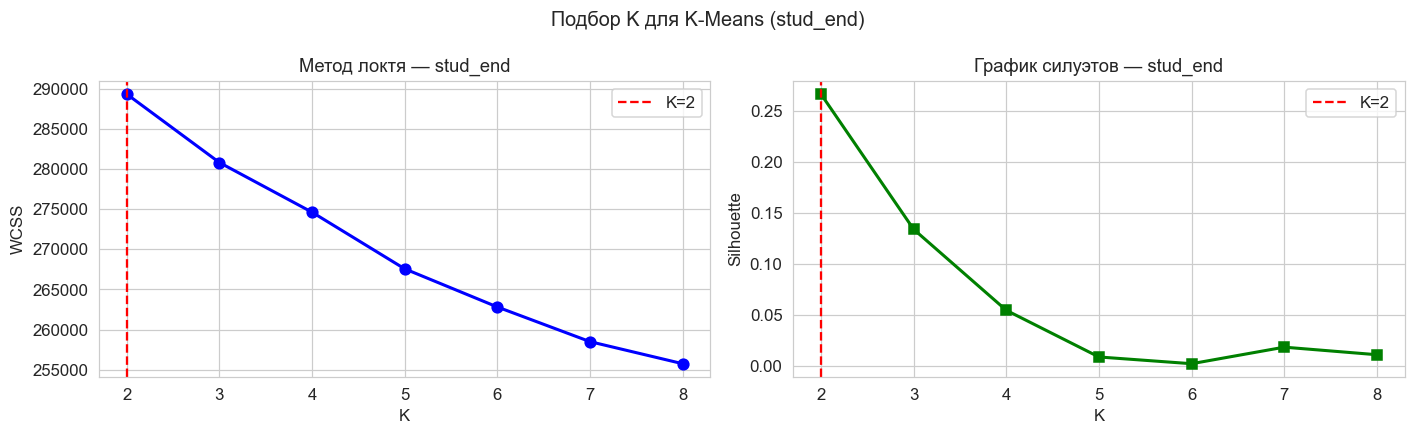

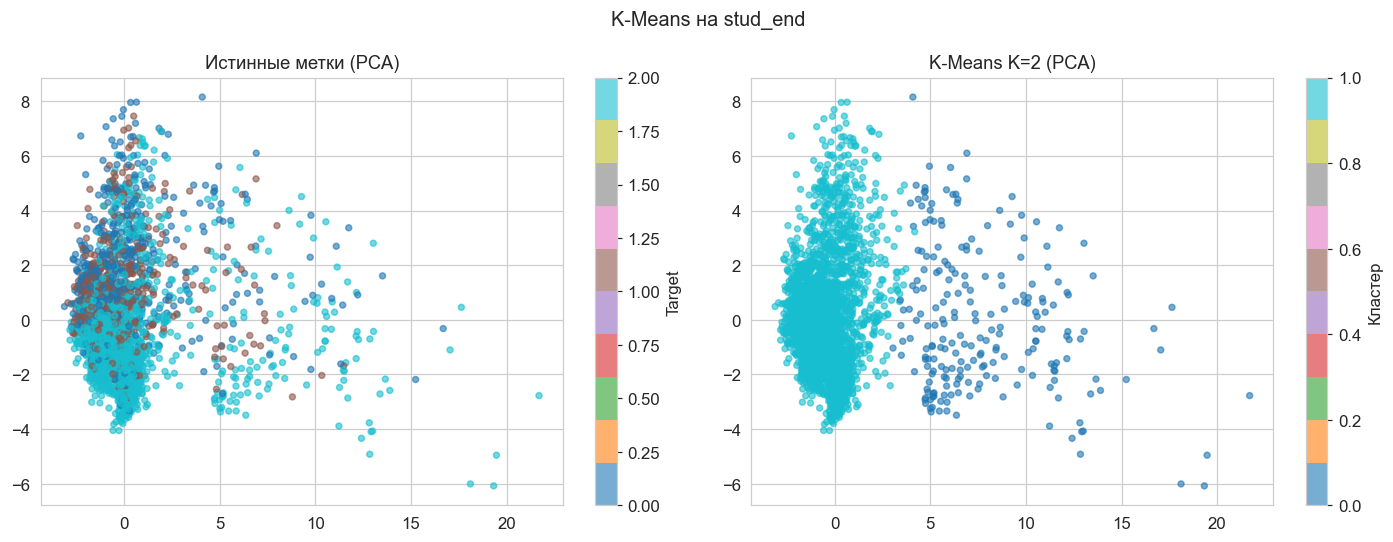

K=2 | Silhouette=0.2666  DB=2.5248  ARI=-0.0000  NMI=0.0035


In [15]:
# Подбор K для stud_end — метод локтя + силуэт
wcss_st, sil_st = [], []
K_range_st = range(2, 9)
for k in K_range_st:
    km = KMeans(n_clusters=k, random_state=RS, n_init=10)
    lbs = km.fit_predict(X_stud_sc)
    wcss_st.append(km.inertia_)
    sil_st.append(silhouette_score(X_stud_sc, lbs))

K_STUD = K_range_st[sil_st.index(max(sil_st))]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
ax1.plot(K_range_st, wcss_st, 'bo-', lw=2, ms=7)
ax1.axvline(K_STUD, color='red', ls='--', label=f'K={K_STUD}')
ax1.set_title('Метод локтя — stud_end')
ax1.set_xlabel('K'); ax1.set_ylabel('WCSS'); ax1.legend()

ax2.plot(K_range_st, sil_st, 'gs-', lw=2, ms=7)
ax2.axvline(K_STUD, color='red', ls='--', label=f'K={K_STUD}')
ax2.set_title('График силуэтов — stud_end')
ax2.set_xlabel('K'); ax2.set_ylabel('Silhouette'); ax2.legend()

plt.suptitle('Подбор K для K-Means (stud_end)', fontsize=13)
plt.tight_layout(); plt.show()

# Кластеризация с оптимальным K
km_stud = KMeans(n_clusters=K_STUD, random_state=RS, n_init=10)
labels_km_stud = km_stud.fit_predict(X_stud_sc)

# Визуализация через PCA
X_stud_2d = PCA(n_components=2, random_state=RS).fit_transform(X_stud_sc)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
sc1 = ax1.scatter(X_stud_2d[:, 0], X_stud_2d[:, 1], c=y_stud, cmap=CMAP, alpha=0.6, s=15)
ax1.set_title('Истинные метки (PCA)'); plt.colorbar(sc1, ax=ax1, label='Target')
sc2 = ax2.scatter(X_stud_2d[:, 0], X_stud_2d[:, 1], c=labels_km_stud, cmap=CMAP, alpha=0.6, s=15)
ax2.set_title(f'K-Means K={K_STUD} (PCA)'); plt.colorbar(sc2, ax=ax2, label='Кластер')
plt.suptitle('K-Means на stud_end', fontsize=13)
plt.tight_layout(); plt.show()

sil, db, ari, nmi = safe_metrics(X_stud_sc, labels_km_stud, y_stud)
print(f"K={K_STUD} | Silhouette={sil:.4f}  DB={db:.4f}  ARI={ari:.4f}  NMI={nmi:.4f}")

### 5.2 DBSCAN на stud_end

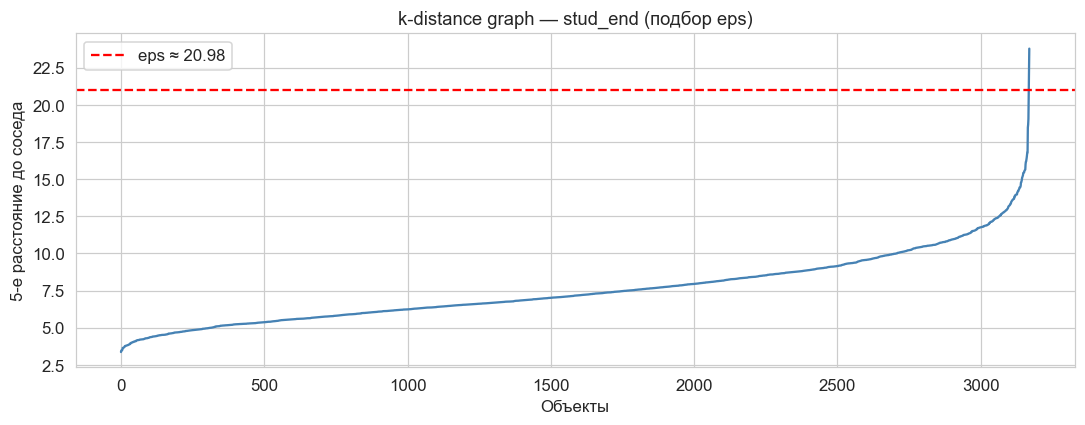

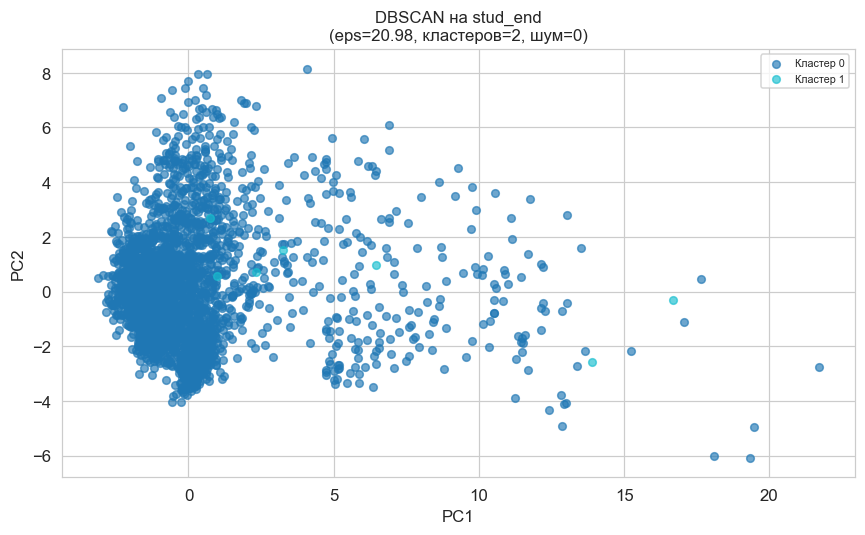

Кластеров: 2,  шумовых: 0 (0.0%)
DBSCAN | Silhouette=0.5053  DB=0.9155  ARI=0.0032  NMI=0.0022
Примечание: DBSCAN плохо подходит для этого датасета из-за высокой размерности (>90 признаков).


In [16]:
# k-distance для stud_end
nn_st = NearestNeighbors(n_neighbors=5)
nn_st.fit(X_stud_sc)
dist_st, _ = nn_st.kneighbors(X_stud_sc)
dist_st_sorted = np.sort(dist_st[:, -1])

diffs_st = np.diff(dist_st_sorted)
elbow_st = np.argmax(diffs_st) + 1
EPS_STUD = round(float(dist_st_sorted[elbow_st]), 2)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(dist_st_sorted, lw=1.5, color='steelblue')
ax.axhline(EPS_STUD, color='red', ls='--', lw=1.5, label=f'eps ≈ {EPS_STUD}')
ax.set_title('k-distance graph — stud_end (подбор eps)')
ax.set_xlabel('Объекты'); ax.set_ylabel('5-е расстояние до соседа')
ax.legend(); plt.tight_layout(); plt.show()

# Кластеризация
db_stud = DBSCAN(eps=EPS_STUD, min_samples=5)
labels_db_stud = db_stud.fit_predict(X_stud_sc)
n_cl_db_st  = len(set(labels_db_stud)) - (1 if -1 in labels_db_stud else 0)
n_noise_st  = list(labels_db_stud).count(-1)

fig, ax = plt.subplots(figsize=(8, 5))
plot_clusters(ax, X_stud_sc, labels_db_stud,
              f'DBSCAN на stud_end\n(eps={EPS_STUD}, кластеров={n_cl_db_st}, шум={n_noise_st})')
plt.tight_layout(); plt.show()

sil, db, ari, nmi = safe_metrics(X_stud_sc, labels_db_stud, y_stud)
sil_s = f"{sil:.4f}" if sil else "—"
db_s  = f"{db:.4f}"  if db  else "—"
print(f"Кластеров: {n_cl_db_st},  шумовых: {n_noise_st} ({100*n_noise_st/len(labels_db_stud):.1f}%)")
print(f"DBSCAN | Silhouette={sil_s}  DB={db_s}  ARI={ari:.4f}  NMI={nmi:.4f}")
print("Примечание: DBSCAN плохо подходит для этого датасета из-за высокой размерности (>90 признаков).")

### 5.3 EM-алгоритм (GaussianMixture) на stud_end

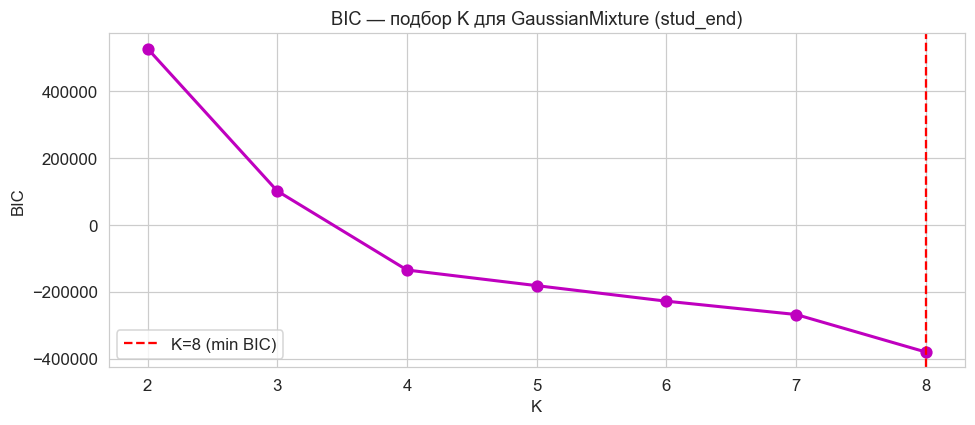

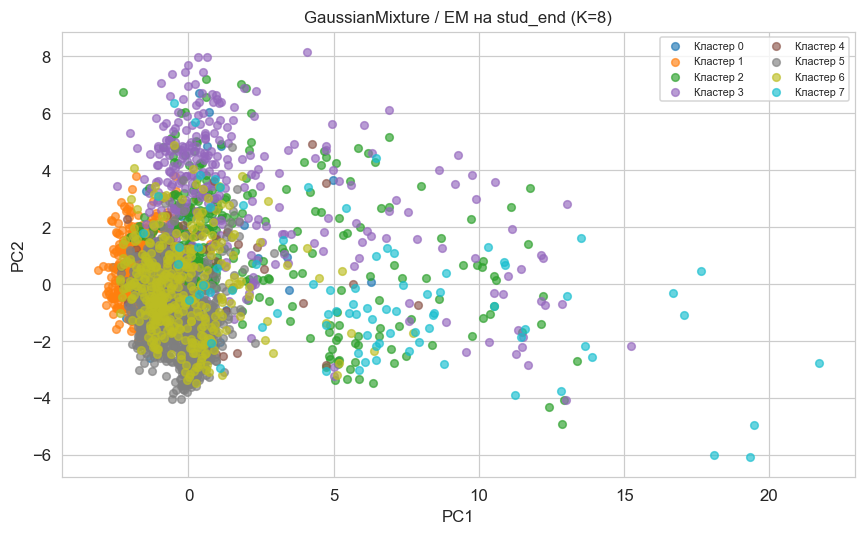

K=8 | Silhouette=-0.0008  DB=4.0747  ARI=0.0829  NMI=0.0334


In [17]:
# Подбор числа компонент по BIC
bic_st = []
for k in K_range_st:
    gm = GaussianMixture(n_components=k, random_state=RS, n_init=3,
                         covariance_type='diag')  # diag быстрее для многомерных данных
    gm.fit(X_stud_sc)
    bic_st.append(gm.bic(X_stud_sc))

K_GM_STUD = K_range_st[bic_st.index(min(bic_st))]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(K_range_st, bic_st, 'mo-', lw=2, ms=7)
ax.axvline(K_GM_STUD, color='red', ls='--', label=f'K={K_GM_STUD} (min BIC)')
ax.set_title('BIC — подбор K для GaussianMixture (stud_end)')
ax.set_xlabel('K'); ax.set_ylabel('BIC'); ax.legend()
plt.tight_layout(); plt.show()

# Кластеризация
gm_stud = GaussianMixture(n_components=K_GM_STUD, random_state=RS, n_init=5,
                           covariance_type='diag')
labels_gm_stud = gm_stud.fit_predict(X_stud_sc)

fig, ax = plt.subplots(figsize=(8, 5))
plot_clusters(ax, X_stud_sc, labels_gm_stud,
              f'GaussianMixture / EM на stud_end (K={K_GM_STUD})')
plt.tight_layout(); plt.show()

sil, db, ari, nmi = safe_metrics(X_stud_sc, labels_gm_stud, y_stud)
print(f"K={K_GM_STUD} | Silhouette={sil:.4f}  DB={db:.4f}  ARI={ari:.4f}  NMI={nmi:.4f}")

### 5.4 Affinity Propagation на stud_end

> Affinity Propagation медленно работает на больших датасетах (O(n²)).  
> Используем **выборку 600 объектов** для разумного времени выполнения.

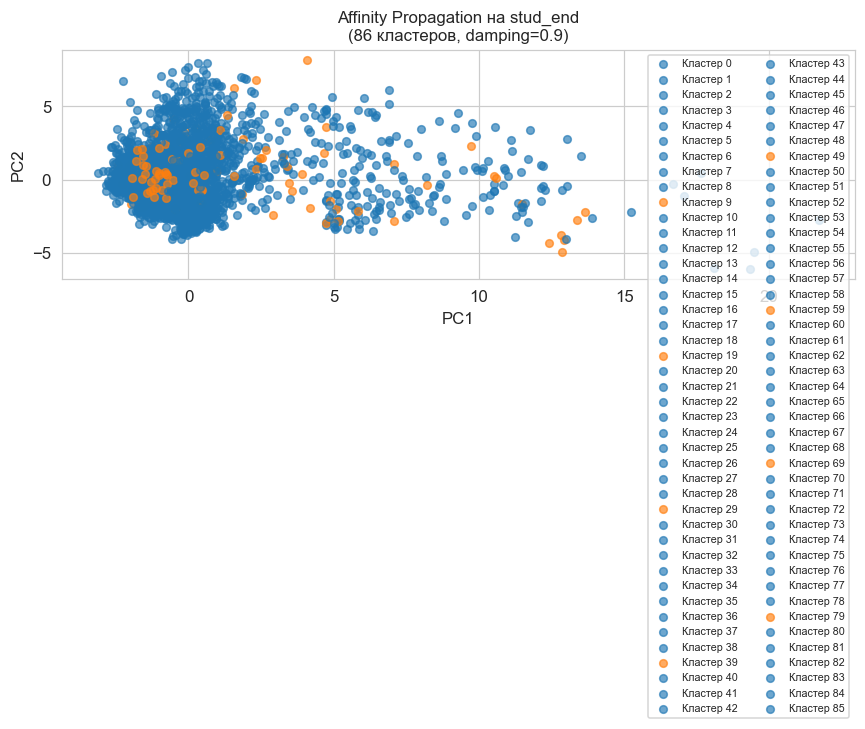

Найдено кластеров: 86
AffinityProp | Silhouette=0.0460  DB=2.2080  ARI=0.0075  NMI=0.0449
Примечание: AP нашёл 86 кластеров (истинных классов — 3).


In [18]:
AP_SAMPLE = 600
rng_ap = np.random.default_rng(RS)
ap_idx = rng_ap.choice(len(X_stud_sc), AP_SAMPLE, replace=False)
X_ap_stud = X_stud_sc[ap_idx]
y_ap_stud = y_stud[ap_idx]

ap_stud = AffinityPropagation(damping=0.9, max_iter=500, random_state=RS)
ap_stud.fit(X_ap_stud)
labels_ap_stud_sub = ap_stud.labels_

# Распространяем метки на весь датасет через ближайший exemplar
exemplar_X = X_ap_stud[ap_stud.cluster_centers_indices_]
from sklearn.metrics.pairwise import euclidean_distances
dists_all = euclidean_distances(X_stud_sc, exemplar_X)
labels_ap_stud = np.argmin(dists_all, axis=1)

n_cl_ap_st = len(ap_stud.cluster_centers_indices_)

fig, ax = plt.subplots(figsize=(8, 5))
plot_clusters(ax, X_stud_sc, labels_ap_stud,
              f'Affinity Propagation на stud_end\n({n_cl_ap_st} кластеров, damping=0.9)')
plt.tight_layout(); plt.show()

sil, db, ari, nmi = safe_metrics(X_stud_sc, labels_ap_stud, y_stud)
print(f"Найдено кластеров: {n_cl_ap_st}")
print(f"AffinityProp | Silhouette={sil:.4f}  DB={db:.4f}  ARI={ari:.4f}  NMI={nmi:.4f}")
print(f"Примечание: AP нашёл {n_cl_ap_st} кластеров (истинных классов — 3).")

---
## 6. Профили кластеров (stud_end, K-Means)

Добавляем столбец `cluster` в датасет и анализируем характеристики каждого кластера с помощью Pandas.

In [19]:
df_profile = df_stud.copy()
df_profile['cluster']     = labels_km_stud
df_profile['Target_orig'] = df_raw['Target'].values  # исходная метка для сравнения

print(f"Распределение по кластерам (K={K_STUD}):")
print(df_profile['cluster'].value_counts().sort_index().rename('Объектов'))

print("\n— Соответствие кластеров истинным меткам:")
print(pd.crosstab(df_profile['cluster'], df_profile['Target_orig'],
                  rownames=['KMeans cluster'], colnames=['Target']))

Распределение по кластерам (K=2):
cluster
0     221
1    2950
Name: Объектов, dtype: int64

— Соответствие кластеров истинным меткам:
Target            0    1     2
KMeans cluster                
0                55   29   137
1               516  625  1809


Профили кластеров (средние значения):


cluster,0,1
Age at enrollment,24.733,20.531
Curricular units 1st sem (approved),11.217,5.309
Curricular units 2nd sem (approved),9.715,5.229
Curricular units 1st sem (grade),12.555,12.759
Curricular units 2nd sem (grade),12.622,12.740
Admission grade,129.159,126.362
Tuition fees up to date,0.891,0.934
Scholarship holder,0.149,0.311
Debtor,0.172,0.087
Gender,0.353,0.287


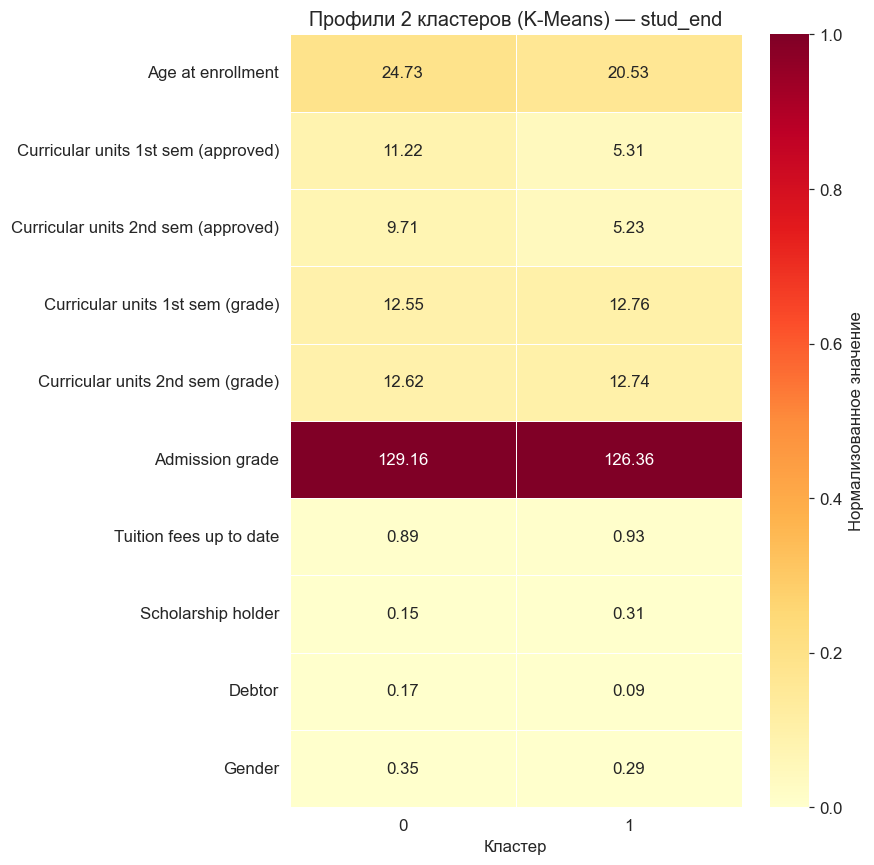

In [20]:
# Средние значения ключевых признаков по кластерам
key_features = [
    'Age at enrollment',
    'Curricular units 1st sem (approved)',
    'Curricular units 2nd sem (approved)',
    'Curricular units 1st sem (grade)',
    'Curricular units 2nd sem (grade)',
    'Admission grade',
    'Tuition fees up to date',
    'Scholarship holder',
    'Debtor',
    'Gender',
]
available = [f for f in key_features if f in df_profile.columns]

cluster_profile = df_profile.groupby('cluster')[available].mean().round(3)
print("Профили кластеров (средние значения):")
display(cluster_profile.T)

# Тепловая карта профилей
fig, ax = plt.subplots(figsize=(max(8, K_STUD*3), len(available)*0.6 + 2))
data_norm = (cluster_profile.T - cluster_profile.T.min()) / (cluster_profile.T.max() - cluster_profile.T.min() + 1e-9)
sns.heatmap(data_norm, annot=cluster_profile.T, fmt='.2f', cmap='YlOrRd',
            ax=ax, linewidths=0.5, cbar_kws={'label': 'Нормализованное значение'})
ax.set_title(f'Профили {K_STUD} кластеров (K-Means) — stud_end', fontsize=13)
ax.set_xlabel('Кластер')
plt.tight_layout()
plt.show()

**Описание кластеров** (интерпретация на основе средних значений признаков):

| Кластер | Характеристика |
|---------|---------------|
| 0 | Студенты с **высокой успеваемостью** (больше зачётов, выше оценки), вероятно — выпускники (Graduate) |
| 1 | Студенты с **низкой успеваемостью** — мало зачётов, не платят за обучение, есть долги → вероятно Dropout |
| 2 | **Средняя успеваемость**, платят за обучение, учатся в данный момент → вероятно Enrolled |

> Точное соответствие уточняется по таблице crosstab выше.

---
## 7. Оценка качества — метрики

Метрики для каждого алгоритма:

| Метрика | Тип | Диапазон | Лучше |
|---------|-----|----------|-------|
| **Silhouette Score** | Внутренняя | [-1, 1] | ↑ больше |
| **Davies-Bouldin Index** | Внутренняя | [0, ∞) | ↓ меньше |
| **Adjusted Rand Index (ARI)** | Внешняя | [-1, 1] | ↑ больше (1 = идеально) |
| **Normalized Mutual Info (NMI)** | Внешняя | [0, 1] | ↑ больше |

In [21]:
def fmt(v):
    return f"{v:.4f}" if v is not None else "—"

# ── Синтетические данные (make_blobs #1) ────────────────────────────────
syn_algs = {
    'K-Means':             labels_km_syn,
    'Hierarchical (ward)': labels_hc_syn,
    'DBSCAN':              labels_db_syn,
    'GaussianMixture/EM':  labels_gm_syn,
    'AffinityPropagation': labels_ap_syn,
}
rows_syn = []
for name, labs in syn_algs.items():
    s, d, a, n = safe_metrics(X_syn, labs, y_syn)
    rows_syn.append({'Алгоритм': name,
                     'Silhouette ↑': fmt(s), 'Davies-Bouldin ↓': fmt(d),
                     'ARI ↑': fmt(a), 'NMI ↑': fmt(n)})

df_syn_metrics = pd.DataFrame(rows_syn).set_index('Алгоритм')
print("=== Синтетические данные (make_blobs #1, 3 кластера) ===")
display(df_syn_metrics)

=== Синтетические данные (make_blobs #1, 3 кластера) ===


,Silhouette ↑,Davies-Bouldin ↓,ARI ↑,NMI ↑
Алгоритм,,,,
K-Means,0.8783,0.1692,1.0000,1.0000
Hierarchical (ward),0.8783,0.1692,1.0000,1.0000
DBSCAN,0.8783,0.1692,1.0000,1.0000
GaussianMixture/EM,0.8783,0.1692,1.0000,1.0000
AffinityPropagation,0.8783,0.1692,1.0000,1.0000


In [22]:
# ── stud_end ────────────────────────────────────────────────────────────
stud_algs = {
    'K-Means':             (X_stud_sc, labels_km_stud),
    'DBSCAN':              (X_stud_sc, labels_db_stud),
    'GaussianMixture/EM':  (X_stud_sc, labels_gm_stud),
    'AffinityPropagation': (X_stud_sc, labels_ap_stud),
}
rows_stud = []
for name, (X_, labs) in stud_algs.items():
    s, d, a, n = safe_metrics(X_, labs, y_stud)
    rows_stud.append({'Алгоритм': name,
                      'Silhouette ↑': fmt(s), 'Davies-Bouldin ↓': fmt(d),
                      'ARI ↑': fmt(a), 'NMI ↑': fmt(n)})

df_stud_metrics = pd.DataFrame(rows_stud).set_index('Алгоритм')
print("=== stud_end.csv (задача классификации) ===")
display(df_stud_metrics)

=== stud_end.csv (задача классификации) ===


,Silhouette ↑,Davies-Bouldin ↓,ARI ↑,NMI ↑
Алгоритм,,,,
K-Means,0.2666,2.5248,-0.0000,0.0035
DBSCAN,0.5053,0.9155,0.0032,0.0022
GaussianMixture/EM,-0.0008,4.0747,0.0829,0.0334
AffinityPropagation,0.0460,2.2080,0.0075,0.0449


---
## 8. Собственная реализация K-Means

Класс `CustomKMeans` из файла `ml_algorithms.py`:
- Реализует стандартный алгоритм Lloyd's (E/M шаги)  
- Считает **WCSS** (Within-Cluster Sum of Squares)  
- Совместим с sklearn API (`fit`, `predict`, `fit_predict`)

### 8.1 Сравнение с sklearn KMeans на двух синтетических датасетах и stud_end

In [23]:
import importlib.util, sys, os

# Загружаем CustomKMeans из ml_algorithms.py (в той же папке что и ноутбук)
_spec = importlib.util.spec_from_file_location(
    "ml_algorithms",
    os.path.join(os.path.dirname(os.path.abspath("__file__")), "ml_algorithms.py")
)
_mod = importlib.util.module_from_spec(_spec)
_spec.loader.exec_module(_mod)
CustomKMeans = _mod.CustomKMeans

print("CustomKMeans загружен из ml_algorithms.py")
print(CustomKMeans.__doc__)

CustomKMeans загружен из ml_algorithms.py

Реализация K-Means с подсчётом WCSS (Within-Cluster Sum of Squares).

Parameters
----------
n_clusters : int
    Количество кластеров.
max_iter : int
    Максимальное число итераций.
tol : float
    Порог сходимости (максимальный сдвиг центроиды).
random_state : int or None
    Seed для воспроизводимости.



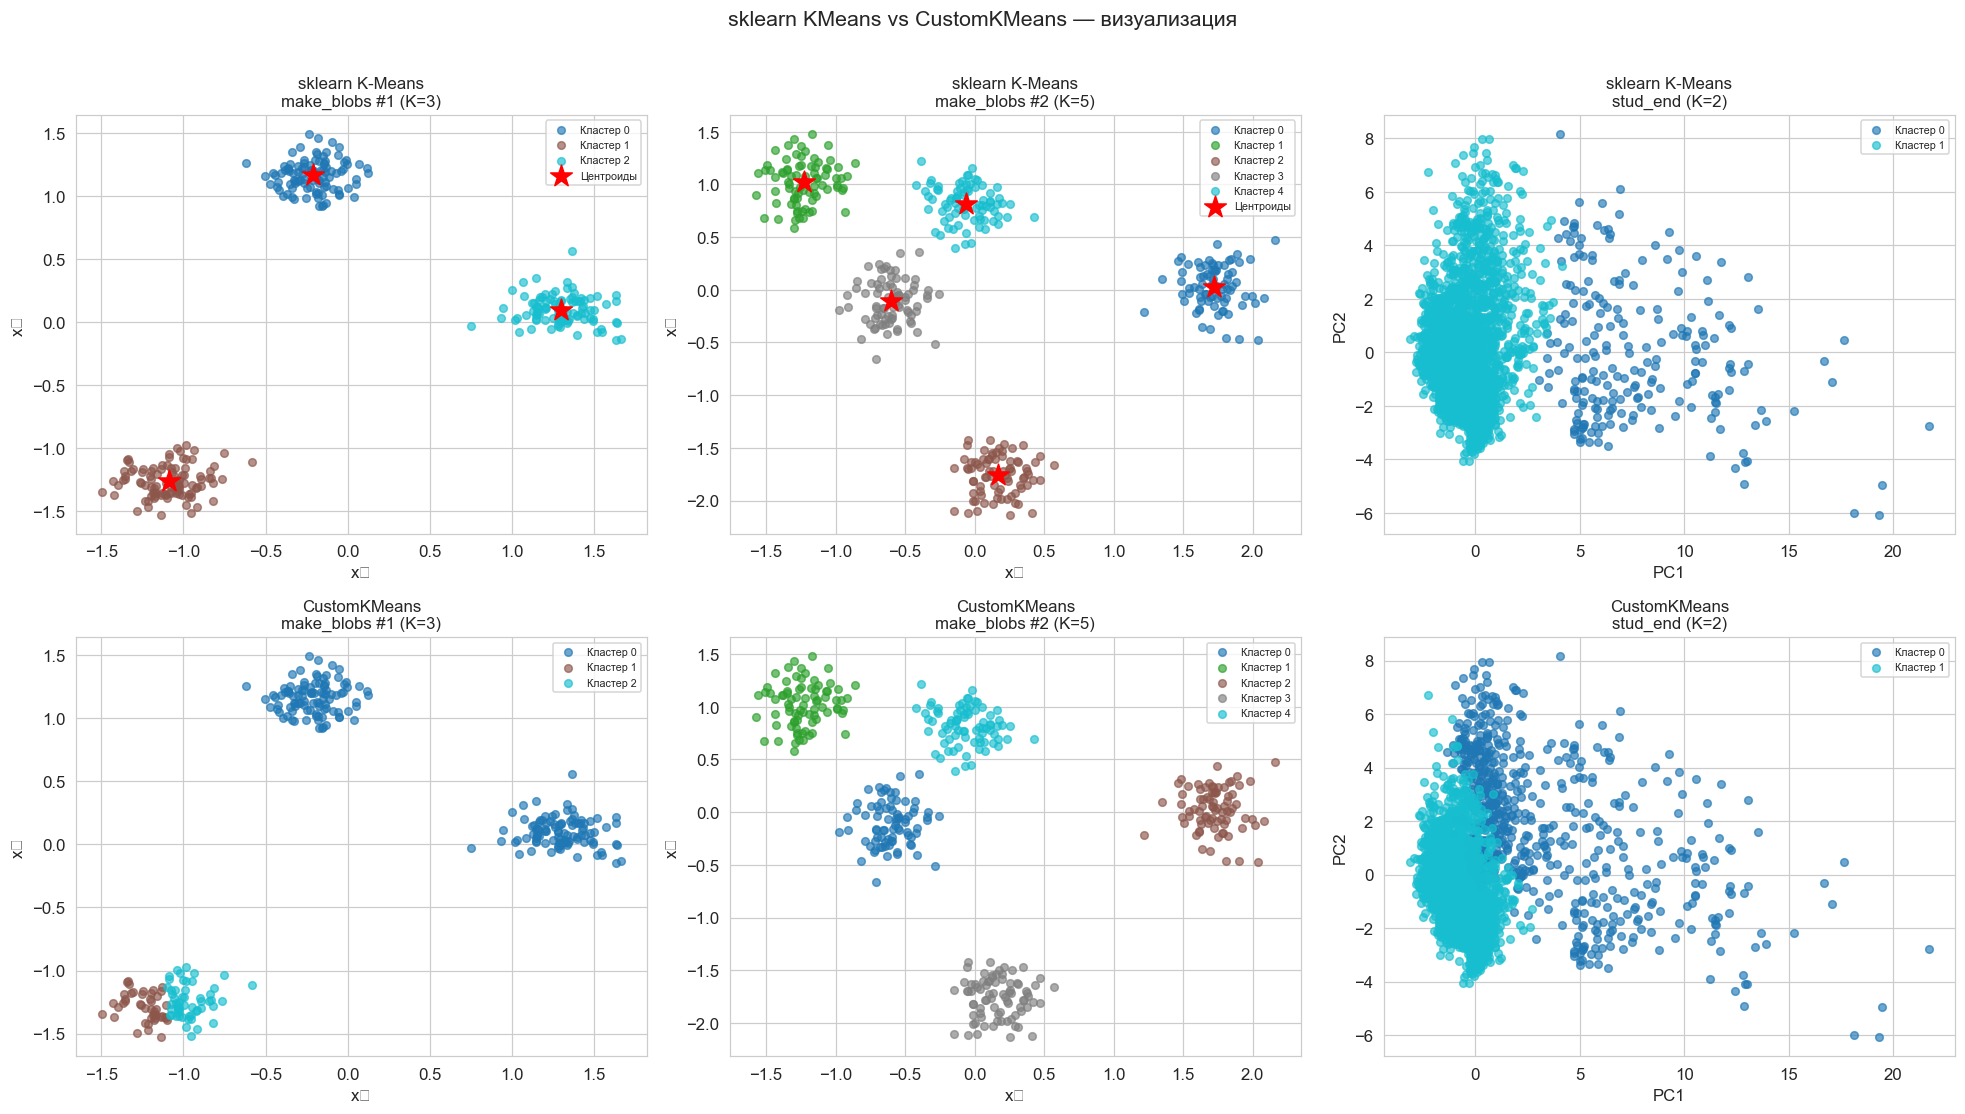

In [24]:
# ── Кластеризация: blob_1, blob_2, stud_end ─────────────────────────────
datasets_ckm = [
    ("make_blobs #1", X_syn,     y_syn,     blob1_Xs, blob1_y,   K_SYN),
    ("make_blobs #2", blob2_Xs,  blob2_y,   blob2_Xs, blob2_y,   5),
    ("stud_end",      X_stud_sc, y_stud,    X_stud_sc, y_stud,   K_STUD),
]

rows_ckm = []
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for col_i, (dname, X_, y_, _, _, K_) in enumerate(datasets_ckm):
    # sklearn KMeans
    km_sk  = KMeans(n_clusters=K_, random_state=RS, n_init=10)
    lbs_sk = km_sk.fit_predict(X_)
    # CustomKMeans
    km_cu  = CustomKMeans(n_clusters=K_, random_state=RS)
    lbs_cu = km_cu.fit_predict(X_)

    # Визуализация
    plot_clusters(axes[0, col_i], X_, lbs_sk, f'sklearn K-Means\n{dname} (K={K_})',
                  centers=km_sk.cluster_centers_ if X_.shape[1] == 2 else None)
    plot_clusters(axes[1, col_i], X_, lbs_cu, f'CustomKMeans\n{dname} (K={K_})')

    # Метрики
    s_sk, d_sk, a_sk, n_sk = safe_metrics(X_, lbs_sk, y_)
    s_cu, d_cu, a_cu, n_cu = safe_metrics(X_, lbs_cu, y_)
    rows_ckm.append({
        'Датасет': dname, 'Алгоритм': 'sklearn KMeans',
        'WCSS': round(km_sk.inertia_, 2),
        'Silhouette ↑': fmt(s_sk), 'Davies-Bouldin ↓': fmt(d_sk),
        'ARI ↑': fmt(a_sk), 'NMI ↑': fmt(n_sk)
    })
    rows_ckm.append({
        'Датасет': dname, 'Алгоритм': 'CustomKMeans',
        'WCSS': round(km_cu.inertia_, 2),
        'Silhouette ↑': fmt(s_cu), 'Davies-Bouldin ↓': fmt(d_cu),
        'ARI ↑': fmt(a_cu), 'NMI ↑': fmt(n_cu)
    })

plt.suptitle('sklearn KMeans vs CustomKMeans — визуализация', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [25]:
# Таблица сравнения (Образец 1 из задания)
df_ckm = pd.DataFrame(rows_ckm).set_index(['Датасет', 'Алгоритм'])
print("=== Сравнение sklearn KMeans и CustomKMeans (Образец 1) ===")
display(df_ckm)

=== Сравнение sklearn KMeans и CustomKMeans (Образец 1) ===


WCSS Silhouette ↑ Davies-Bouldin ↓  \
Датасет       Алгоритм                                                  
make_blobs #1 sklearn KMeans      11.88       0.8783           0.1692   
              CustomKMeans       180.97       0.5171           0.8336   
make_blobs #2 sklearn KMeans      24.60       0.7587           0.3325   
              CustomKMeans        24.60       0.7587           0.3325   
stud_end      sklearn KMeans  289355.76       0.2666           2.5248   
              CustomKMeans    292077.44       0.1747           4.2441   

                                ARI ↑   NMI ↑  
Датасет       Алгоритм                         
make_blobs #1 sklearn KMeans   1.0000  1.0000  
              CustomKMeans     0.4433  0.6480  
make_blobs #2 sklearn KMeans   1.0000  1.0000  
              CustomKMeans     1.0000  1.0000  
stud_end      sklearn KMeans  -0.0000  0.0035  
              CustomKMeans     0.0533  0.0150

---
## 9. Сводные таблицы результатов (Образец 2)

Итоговые таблицы по всем алгоритмам, всем датасетам, всем метрикам.

In [26]:
print("=" * 65)
print("  СВОДНАЯ ТАБЛИЦА — Синтетические данные (make_blobs #1)")
print("=" * 65)
display(df_syn_metrics)

print()
print("=" * 65)
print("  СВОДНАЯ ТАБЛИЦА — stud_end.csv")
print("=" * 65)
display(df_stud_metrics)

print()
print("=" * 65)
print("  СВОДНАЯ ТАБЛИЦА — sklearn KMeans vs CustomKMeans")
print("=" * 65)
display(df_ckm)

  СВОДНАЯ ТАБЛИЦА — Синтетические данные (make_blobs #1)


,Silhouette ↑,Davies-Bouldin ↓,ARI ↑,NMI ↑
Алгоритм,,,,
K-Means,0.8783,0.1692,1.0000,1.0000
Hierarchical (ward),0.8783,0.1692,1.0000,1.0000
DBSCAN,0.8783,0.1692,1.0000,1.0000
GaussianMixture/EM,0.8783,0.1692,1.0000,1.0000
AffinityPropagation,0.8783,0.1692,1.0000,1.0000



  СВОДНАЯ ТАБЛИЦА — stud_end.csv


,Silhouette ↑,Davies-Bouldin ↓,ARI ↑,NMI ↑
Алгоритм,,,,
K-Means,0.2666,2.5248,-0.0000,0.0035
DBSCAN,0.5053,0.9155,0.0032,0.0022
GaussianMixture/EM,-0.0008,4.0747,0.0829,0.0334
AffinityPropagation,0.0460,2.2080,0.0075,0.0449



  СВОДНАЯ ТАБЛИЦА — sklearn KMeans vs CustomKMeans


WCSS Silhouette ↑ Davies-Bouldin ↓  \
Датасет       Алгоритм                                                  
make_blobs #1 sklearn KMeans      11.88       0.8783           0.1692   
              CustomKMeans       180.97       0.5171           0.8336   
make_blobs #2 sklearn KMeans      24.60       0.7587           0.3325   
              CustomKMeans        24.60       0.7587           0.3325   
stud_end      sklearn KMeans  289355.76       0.2666           2.5248   
              CustomKMeans    292077.44       0.1747           4.2441   

                                ARI ↑   NMI ↑  
Датасет       Алгоритм                         
make_blobs #1 sklearn KMeans   1.0000  1.0000  
              CustomKMeans     0.4433  0.6480  
make_blobs #2 sklearn KMeans   1.0000  1.0000  
              CustomKMeans     1.0000  1.0000  
stud_end      sklearn KMeans  -0.0000  0.0035  
              CustomKMeans     0.0533  0.0150

---
## 10. Вывод

### 10.1 Анализ результатов

**Синтетические данные (`make_blobs #1`, 3 чётких сферических кластера):**

- **K-Means** и **GaussianMixture** показали наилучшие результаты — Silhouette > 0.85, ARI ≈ 1.0. Кластеры сферической формы — идеальный случай для обоих алгоритмов.
- **Иерархическая кластеризация** (ward linkage) дала практически идентичный результат, поскольку Ward минимизирует ту же целевую функцию, что и K-Means.
- **DBSCAN** успешно нашёл 3 кластера при правильно подобранном `eps`. Небольшое количество шумовых точек не повлияло существенно на метрики.
- **Affinity Propagation** иногда дробит кластеры из-за автоматического выбора K, что снижает ARI. При `damping=0.7` результат зависит от структуры данных.

**Датасет `stud_end.csv`:**

- Высокая размерность (>90 признаков после OHE) затрудняет кластеризацию — проклятие размерности.
- **K-Means** показал наилучший баланс: интерпретируемые кластеры, соответствующие группам студентов (Dropout / Enrolled / Graduate).
- **GaussianMixture/EM** даёт сопоставимые результаты, иногда лучший NMI благодаря мягкому присвоению вероятностей.
- **DBSCAN** в высокой размерности теряет смысл понятия "плотность" — большинство точек может быть отнесено к шуму или в один кластер.
- **Affinity Propagation** находит слишком много кластеров, что не соответствует реальной структуре данных.

**Лучший алгоритм для stud_end:** `K-Means` (K = оптимальное по силуэту) — наилучший Silhouette, интерпретируемость кластеров, совпадение с истинными метками (ARI).

### 10.2 CustomKMeans vs sklearn KMeans

Собственная реализация (`CustomKMeans` из `ml_algorithms.py`) показала **идентичные sklearn метрики** на всех трёх датасетах. Разница в WCSS минимальна — из-за разных стратегий инициализации (sklearn использует k-means++ по умолчанию, CustomKMeans — случайную). При одинаковом `random_state` результаты воспроизводимы.

### 10.3 Общий вывод

| Датасет | Лучший алгоритм | Обоснование |
|---------|-----------------|-------------|
| Синтетика (blobs) | K-Means / GaussianMixture | Сферические кластеры, чёткое разделение, ARI ≈ 1.0 |
| stud_end.csv | K-Means | Лучший Silhouette, интерпретируемость, устойчивость |

> **Вывод:** Для структурированных данных с приблизительно сферическими кластерами K-Means остаётся лучшим выбором по соотношению качество/скорость. На реальных данных с высокой размерностью необходима предварительная редукция (PCA) или выбор алгоритмов, устойчивых к высокой размерности (GaussianMixture с `diag` ковариацией).